#### <span style="color:cyan">**Imports**</span>

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *
from util.classes.PCAPeakDataset import *
from util.classes.PcaPeakMLP import *
from util.model_eval import *
from util.model_optimization import *

from preprocessing.pipelines import build_pca_pipeline
import json
import os
import math
import numpy as np
import torch

#### <span style="color:cyan">**Data Preprocessing**</span>

PCA Feature Table (abs):
              pc_0      pc_1      pc_2      pc_3      pc_4  ...     pc_20  \
run_id                                                      ...             
run_0001 -2.217374  0.929584 -2.473297 -2.080936 -0.927886  ...  0.066816   
run_0002 -1.260568  2.485576 -1.960000 -0.449555  0.556877  ... -0.039305   
run_0003 -2.409136 -1.940734  2.035820 -0.248347  1.594865  ... -0.056005   
run_0004  4.479123 -2.959439 -0.625314 -1.815858  0.071271  ... -0.003186   
run_0005  0.363459  2.232888  1.253392 -0.963245  1.894123  ... -0.106318   

             pc_21     pc_22     pc_23     pc_24  
run_id                                            
run_0001  0.009753 -0.085810 -0.013698 -0.021518  
run_0002 -0.086259 -0.052469  0.046247 -0.002160  
run_0003  0.072037 -0.004185 -0.049986 -0.075402  
run_0004  0.069677  0.019447  0.119227 -0.036423  
run_0005 -0.176590 -0.088627  0.144734 -0.091509  

[5 rows x 25 columns]

Peak Feature Table (abs, N=4, from multi_peak_ft.pkl):

c:\Users\robert\Code\capstone\capstone_SiC_gratings\ML_project\util\pca_plotting.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


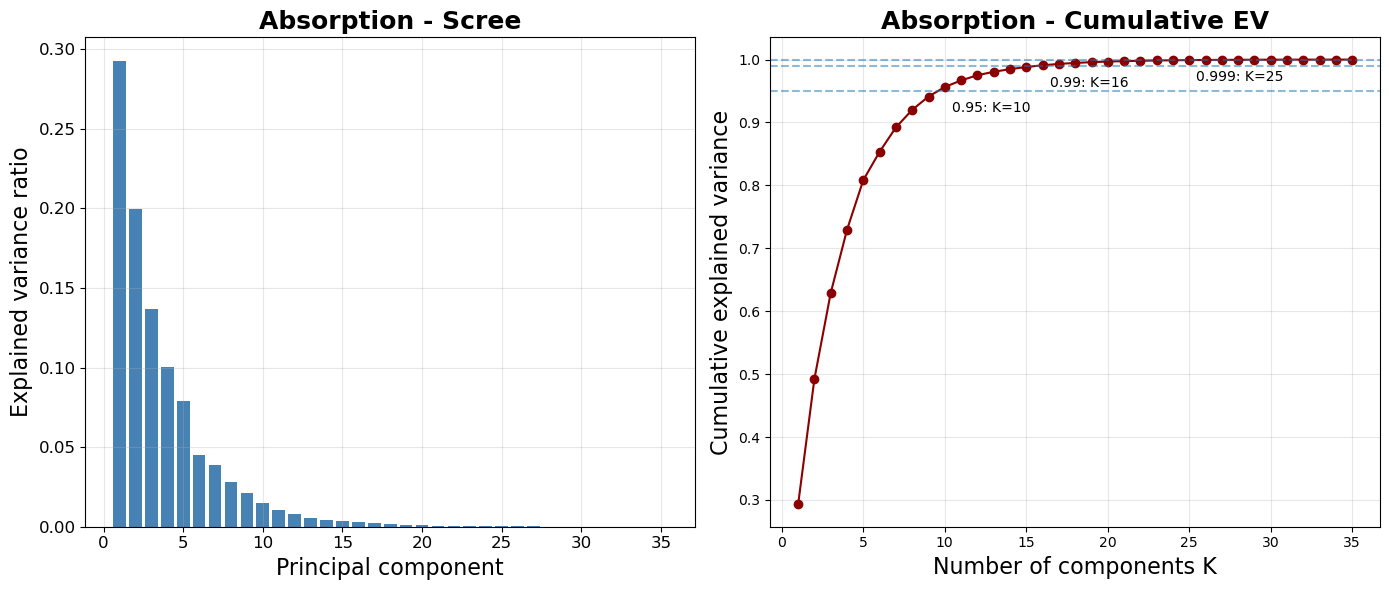

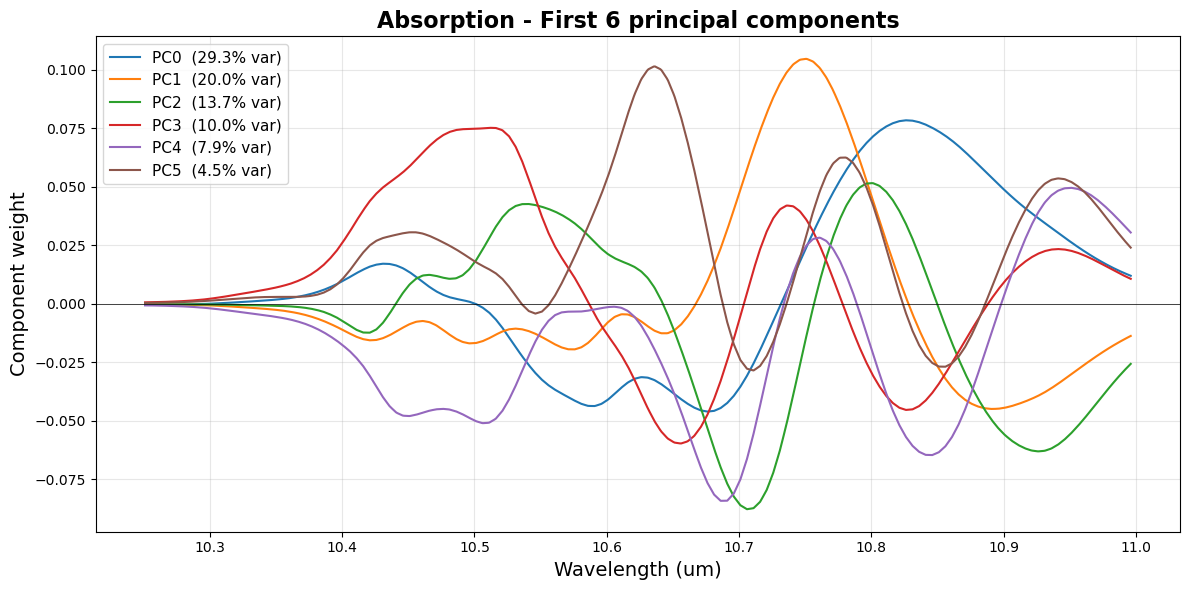

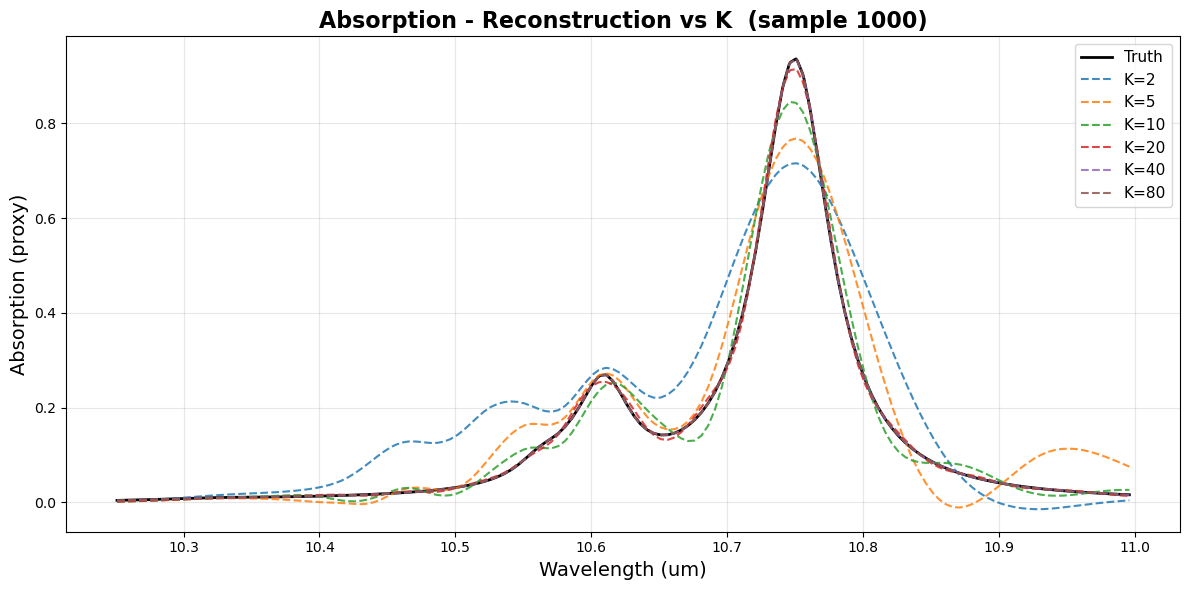

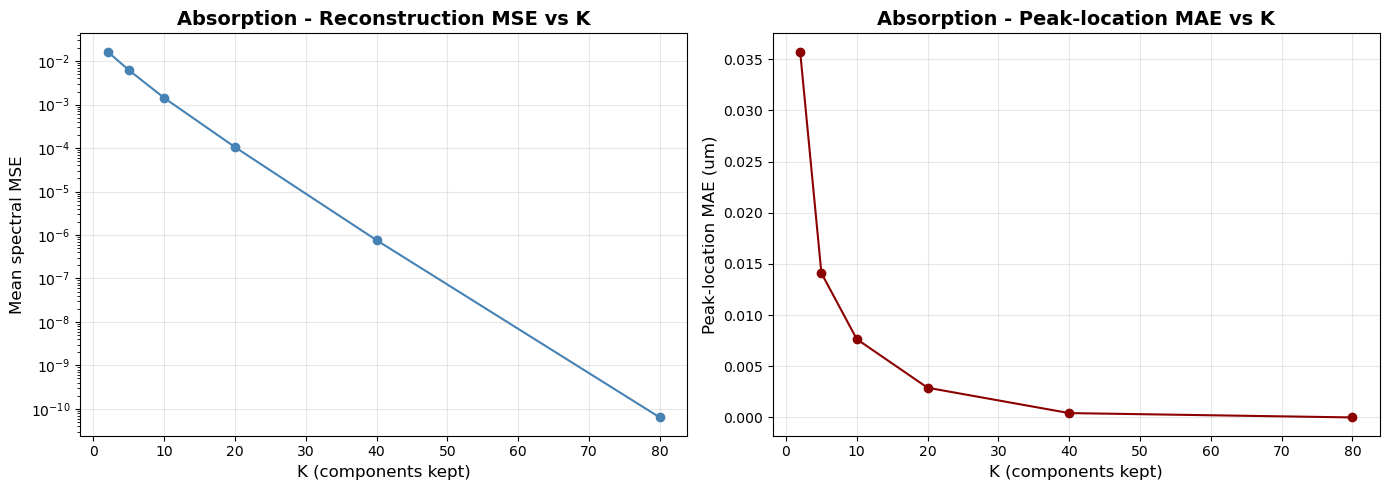

Absorption K-sweep:
  K=  2  MSE=1.661e-02  peak-MAE=0.0357 um
  K=  5  MSE=6.267e-03  peak-MAE=0.0141 um
  K= 10  MSE=1.429e-03  peak-MAE=0.0076 um
  K= 20  MSE=1.054e-04  peak-MAE=0.0029 um
  K= 40  MSE=7.600e-07  peak-MAE=0.0004 um
  K= 80  MSE=6.350e-11  peak-MAE=0.0000 um


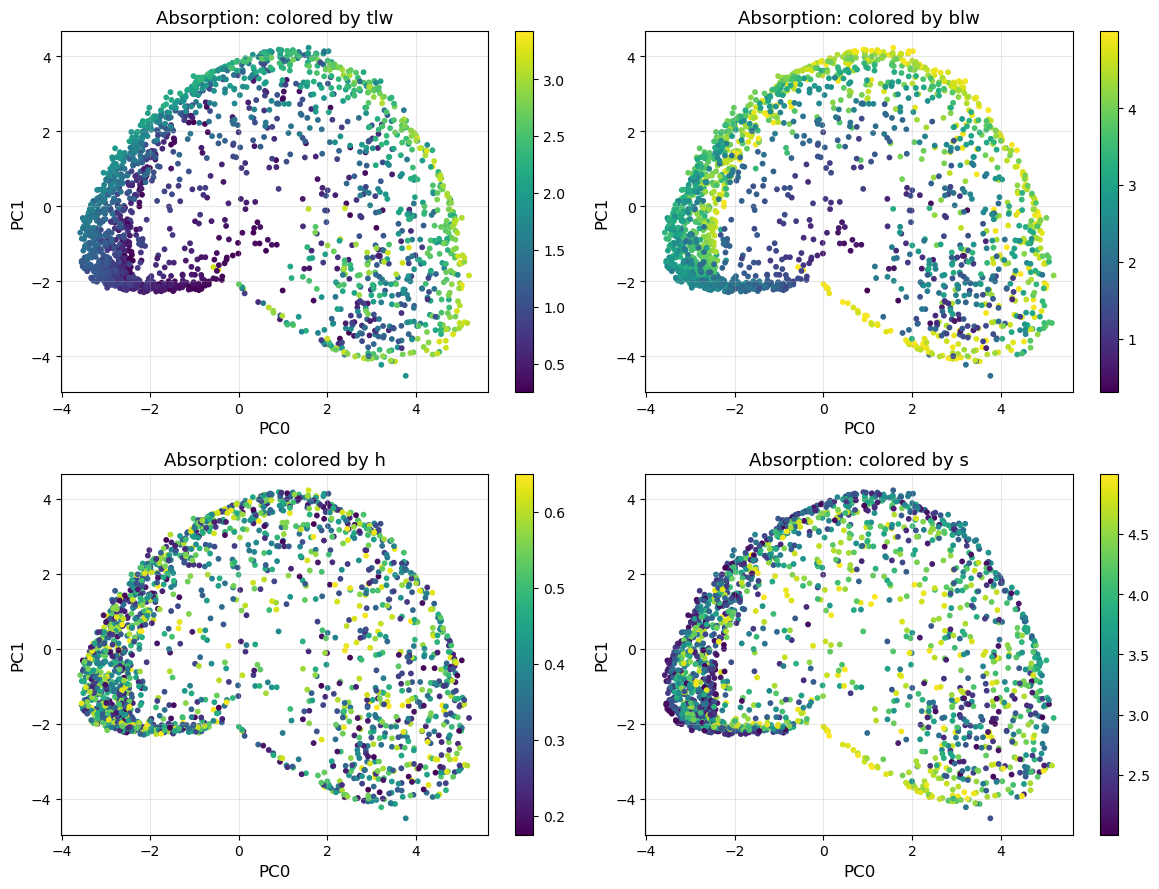

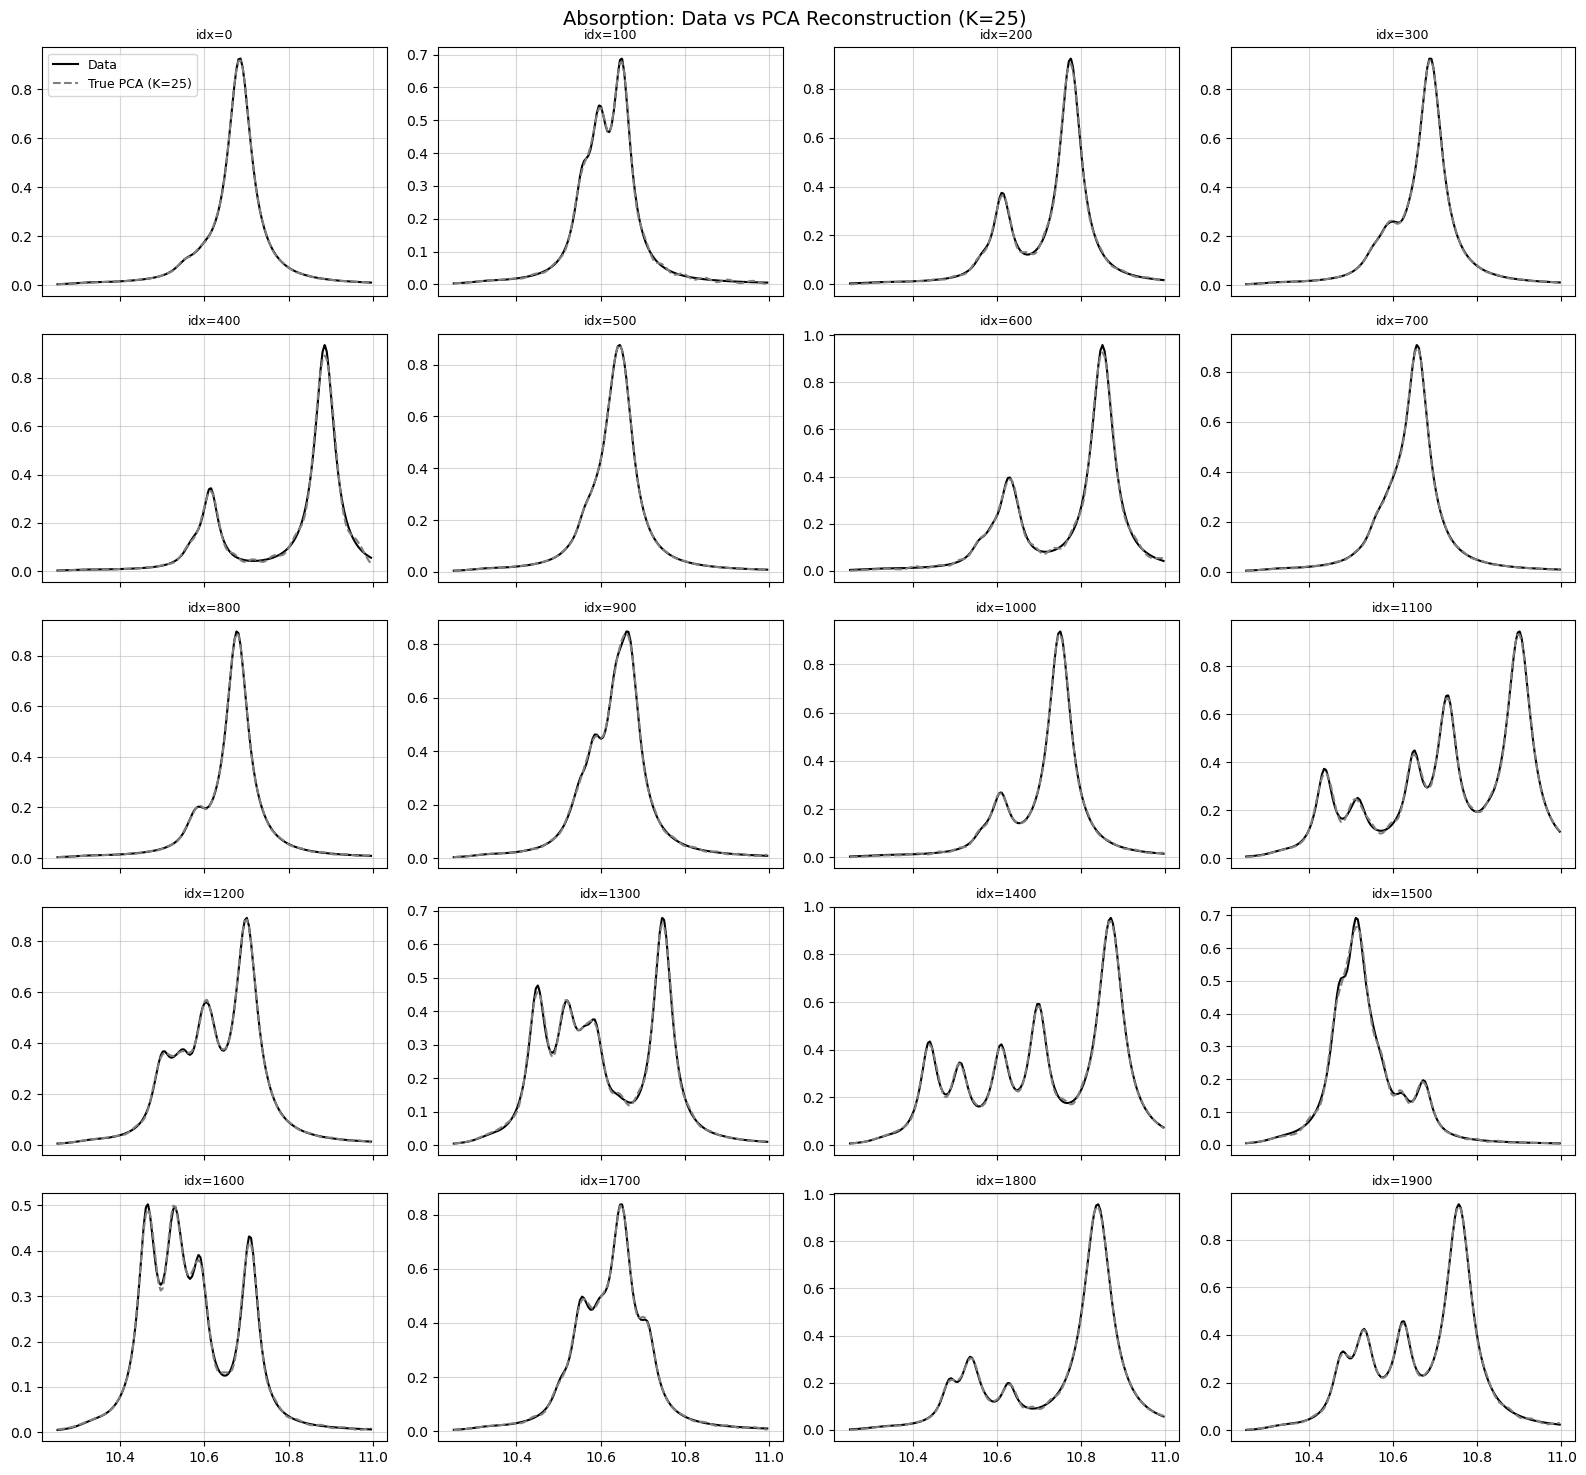

In [2]:
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
INTERP = 4
TEST_IDX = np.arange(0, 1947, 100)
K = 25
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# BLW/TLW ratio filter. Set MIN_BLW_TLW_RATIO > 0 to drop samples below it.
# Set MAX_BLW_TLW_RATIO to a number to drop samples at or above it; when set,
# a lower floor of 1 is enforced automatically. Either or both may be active.
MIN_BLW_TLW_RATIO = 0
MAX_BLW_TLW_RATIO = None

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Filter samples by BLW/TLW ratio
if MIN_BLW_TLW_RATIO > 0 or MAX_BLW_TLW_RATIO is not None:
    ratio = geom_table['blw'] / geom_table['tlw']
    keep_mask = pd.Series(True, index=geom_table.index)
    if MIN_BLW_TLW_RATIO > 0:
        keep_mask &= (ratio >= MIN_BLW_TLW_RATIO)
    if MAX_BLW_TLW_RATIO is not None:
        keep_mask &= (ratio >= 1) & (ratio < MAX_BLW_TLW_RATIO)
    n_before = len(geom_table)
    geom_table = geom_table.loc[keep_mask].reset_index(drop=True)
    refl_data  = refl_data.loc[keep_mask].reset_index(drop=True)
    abs_data   = abs_data.loc[keep_mask].reset_index(drop=True)
    print(f'BLW/TLW filter (min={MIN_BLW_TLW_RATIO}, max={MAX_BLW_TLW_RATIO}): kept {len(geom_table)}/{n_before} samples')
    # Re-space TEST_IDX evenly across the filtered sample space (same count as before)
    TEST_IDX = np.linspace(0, len(geom_table) - 1, len(TEST_IDX)).astype(int)

# Load peak features from pickle â€” same source the optimizer used.
# multi_peak_extraction() output: columns [lambda_0..N, Q_0..N, mask_0..N]
with open('../multi_peak_ft.pkl', 'rb') as f:
    multi_peak_ft = pickle.load(f)
abs_ft_peak = multi_peak_ft['absorption_features']
N_PEAKS = multi_peak_ft['peak_count']

# Build PCA pipeline
abs_pipe_pca  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)

# Fit pipeline and extract relevant data
abs_ft_pca  = abs_pipe_pca.fit_transform(abs_data) # PCA coefficients
abs_pca  = abs_pipe_pca.named_steps['pca'].artifacts_ # PCA artifacts
abs_data  = abs_pipe_pca[:-1].fit_transform(abs_data) # Spectrum just before PCA
wl = abs_data.columns.to_numpy(dtype=float) # wavelength axis

# Print Feature tables for inspection
print(f'PCA Feature Table (abs):\n{abs_ft_pca.head()}\n')
print(f'Peak Feature Table (abs, N={N_PEAKS}, from multi_peak_ft.pkl):\n{abs_ft_peak.head()}\n')


# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=35)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 4).
plot_latent_colored_by_geom(abs_ft_pca, geom_table, geom_labels, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


# Data dictionaries for later
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_pca_features": abs_ft_pca,
    "absorption_peak_features": abs_ft_peak,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels,
    "geometry_table": geom_table,
    "K": K,
    "N_peaks": N_PEAKS,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "peak_source": "multi_peak_ft.pkl",
    "n_peaks": N_PEAKS,
    "K": K,
    "geometry_dim": 4,
    "min_blw_tlw_ratio": MIN_BLW_TLW_RATIO,
    "max_blw_tlw_ratio": MAX_BLW_TLW_RATIO,
}

#### <span style="color:cyan">**Training - Configuration**</span>

In [10]:
ROOT = "trained_models/pca_4D"
NAME = "pca_4D_phys"
DIR = f'{ROOT}/{NAME}'
os.makedirs(f'{DIR}', exist_ok=True)
os.makedirs(f'{DIR}/config', exist_ok=True)
os.makedirs(f'{DIR}/models', exist_ok=True)
os.makedirs(f'{DIR}/results', exist_ok=True)

#### CONFIG ####
loader_config = {
    "seed": 1234,
    "test_ratio": 0.15,
    "splits": 4,
    "pre_split": {},
    "shuffle": True,
    "batch_size": 32
}
MLP_config = {
    "hidden_dim": 256,
    "n_layers": 4,
    "k": K,
    "p": 0.000,
    "n_peaks": N_PEAKS,
    'input_dim': 4
}
train_config = {
    "epochs": 1000,
    "lr": 3.414e-3,
    "wd": 7.733e-5,
    "patience": 60,
    "peak_loss_weight": 6.124e-03,
    "path": f'{DIR}/models'
}

#### SETUP OBJECTS ####
data = PCAPeakDataset(
    pca_ft['geometry_table'],
    pca_ft['absorption_pca_features'],
    pca_ft['absorption_peak_features'],
    pca_ft['absorption_pca'],
    normalize_geom = True,
    normalize_pca = False,
    normalize_amp = True
)

# Raw absorption spectra aligned with dataset order (used for 3-curve plots)
_sorted_ids = pca_ft['geometry_table'].sort_index().index
_raw_abs = pca_ft['absorption'].loc[_sorted_ids].to_numpy()

kf_indices, test_indices = generate_kfold(
    data,
    loader_config['splits'],
    loader_config['seed'],
    loader_config['test_ratio']
)
train_config['test_indices'] = test_indices

#### <span style="color:cyan">**Training - CV**</span>

In [11]:
#### TRAINING LOOP ####
fold_metrics = {
    "best_val_coeff_mse":  [],
    "best_val_recon_mse":  [],
    "best_val_recon_rmse": [],
    "peak_mae":            [],
    "peak_loc_error_um":   [],
    "train_val_gap_coeff": [],
    "best_epoch":          [],
    "epochs_trained":      [],
}
fold_histories = []

wl_tensor = torch.tensor(np.asarray(data.wl), dtype=torch.float32)

def seed_everything(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

for i, (train_idx, val_idx) in enumerate(kf_indices):
    os.makedirs(f'{train_config["path"]}/fold{i}', exist_ok=True)
    seed_everything(loader_config['seed'] + i)
    
    model = PcaPeakMLP(
        MLP_config['k'],
        MLP_config["hidden_dim"],
        MLP_config["n_layers"],
        MLP_config['p'],
        MLP_config['n_peaks'],
        input_dim=MLP_config["input_dim"]
    )

    train_loader, val_loader = create_dataloader_kfold(
        data,
        loader_config['seed'],
        train_idx,
        val_idx,
        loader_config['batch_size']
    )

    model_state, history = train_pca_regression(
        model,
        data,
        train_loader,
        val_loader,
        train_config["epochs"],
        train_config['lr'],
        train_config["wd"],
        train_config["patience"],
        f'{train_config["path"]}/fold{i}',
        peak_loss_weight=train_config["peak_loss_weight"],
    )
    fold_histories.append(history)

    best_ep = history["stop_epoch"]
    best_val_coeff   = history["val_loss"][best_ep]
    best_val_recon   = history["val_loss_recon"][best_ep]
    best_train_coeff = history["train_loss"][best_ep]

    # Spectrum-level peak metrics on val set with best-epoch weights
    model.eval()
    peak_abs_errs = []
    peak_loc_errs = []
    with torch.no_grad():
        for geom, pca_feat, amp_feat, mask in val_loader:
            pca_pred, _ = model(geom)
            pred_spec = data.reconstruct_spectrum(pca_pred)
            true_spec = data.reconstruct_spectrum(pca_feat)
            pred_peak = pred_spec.max(dim=-1)
            true_peak = true_spec.max(dim=-1)
            peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
            peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())
    peak_mae    = torch.cat(peak_abs_errs).mean().item()
    peak_loc_err = torch.cat(peak_loc_errs).mean().item()

    fold_metrics["best_val_coeff_mse"].append(float(best_val_coeff))
    fold_metrics["best_val_recon_mse"].append(float(best_val_recon))
    fold_metrics["best_val_recon_rmse"].append(float(math.sqrt(best_val_recon)))
    fold_metrics["peak_mae"].append(float(peak_mae))
    fold_metrics["peak_loc_error_um"].append(float(peak_loc_err))
    fold_metrics["train_val_gap_coeff"].append(float(best_val_coeff - best_train_coeff))
    fold_metrics["best_epoch"].append(int(best_ep))
    fold_metrics["epochs_trained"].append(int(len(history["val_loss"])))

Early stopping triggered at epoch 157
Early stopping triggered at epoch 146
Early stopping triggered at epoch 195
Early stopping triggered at epoch 124


#### <span style="color:cyan">**Training - Final Model (all non-test)**</span>

In [12]:
#### FINAL MODEL ####
os.makedirs(f'{train_config["path"]}/final_model', exist_ok=True)

non_test_idx = np.setdiff1d(np.arange(len(data)), test_indices)
final_epochs = int(math.ceil(float(np.mean(fold_metrics["best_epoch"]) + np.std(fold_metrics["best_epoch"]))))

final_model_net = PcaPeakMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    MLP_config['n_peaks'],
    input_dim=MLP_config["input_dim"]
)

final_train_loader, test_loader = create_dataloader_kfold(
    data,
    loader_config['seed'],
    non_test_idx,
    test_indices,
    loader_config['batch_size']
)

_, final_history = train_pca_regression_final(
    final_model_net,
    data,
    final_train_loader,
    final_epochs,
    train_config['lr'],
    train_config['wd'],
    f'{train_config["path"]}/final_model',
    peak_loss_weight=train_config["peak_loss_weight"],
)

# Single honest evaluation on test_indices
final_model_net.eval()
test_coeff_sum = 0.0
test_recon_sum = 0.0
test_samples = 0
peak_abs_errs = []
peak_loc_errs = []
_mse = torch.nn.MSELoss()
with torch.no_grad():
    for geom, pca_feat, amp_feat, mask in test_loader:
        pca_pred, _ = final_model_net(geom)
        pred_spec = data.reconstruct_spectrum(pca_pred)
        true_spec = data.reconstruct_spectrum(pca_feat)

        batch_n = geom.shape[0]
        test_coeff_sum += _mse(pca_pred, pca_feat).item() * batch_n
        test_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        test_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

test_coeff_mse = test_coeff_sum / max(test_samples, 1)
test_recon_mse = test_recon_sum / max(test_samples, 1)
final_peak_mae = torch.cat(peak_abs_errs).mean().item()
final_peak_loc = torch.cat(peak_loc_errs).mean().item()
final_train_coeff = final_history["train_loss"][-1]
final_train_recon = final_history["train_loss_recon"][-1]

final_metrics = {
    "test_coeff_mse":        float(test_coeff_mse),
    "test_coeff_rmse":       float(math.sqrt(test_coeff_mse)),
    "test_recon_mse":        float(test_recon_mse),
    "test_recon_rmse":       float(math.sqrt(test_recon_mse)),
    "peak_mae":              float(final_peak_mae),
    "peak_loc_error_um":     float(final_peak_loc),
    "train_test_gap_coeff":  float(test_coeff_mse - final_train_coeff),
    "train_test_gap_recon":  float(test_recon_mse - final_train_recon),
    "epochs_trained":        int(final_epochs),
    "n_train":               int(len(non_test_idx)),
    "n_test":                int(len(test_indices)),
}

Final | Epoch 001/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.545402 | Loss Peak: 0.625053 | RECON: 1.816e-02
Final | Epoch 002/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.256107 | Loss Peak: 0.486311 | RECON: 8.526e-03
Final | Epoch 003/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.173826 | Loss Peak: 0.447377 | RECON: 5.786e-03
Final | Epoch 004/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.133766 | Loss Peak: 0.417142 | RECON: 4.453e-03
Final | Epoch 005/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.141423 | Loss Peak: 0.426519 | RECON: 4.708e-03
Final | Epoch 006/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.101517 | Loss Peak: 0.407535 | RECON: 3.379e-03
Final | Epoch 007/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.093225 | Loss Peak: 0.398299 | RECON: 3.103e-03
Final | Epoch 008/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.089947 | Loss Peak: 0.400795 | RECON: 2.994e-03
Final | Epoch 009/121 | K= 25 | lr=3.41e-03 | Loss PCA: 0.100437 | Loss Peak: 0.395076 | RECON: 3.343e-03
Final | Epoch 010/121 | K= 25 | lr=3.41e-03 | 

In [13]:
#### AGGREGATE + SAVE ####
summary = {
    k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
    for k, v in fold_metrics.items()
}
kfold_results = {
    "config": {
        "data": data_config,
        "loader": loader_config,
        "model": MLP_config,
        "training": {k: v for k, v in train_config.items() if k != "path"},
    },
    "per_fold": fold_metrics,
    "summary": summary,
    "final_model": final_metrics,
}
def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    raise TypeError(f"Not JSON serializable: {type(o).__name__}")

with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


#### PRINT SUMMARY ####
name_w = max(len(k) for k in summary) + 2
print(f"\n{'='*72}")
print(f"K-Fold Summary  ({loader_config['splits']} folds)  -  {NAME}")
print(f"{'='*72}")
print(f"{'metric':<{name_w}} {'mean':>12} {'std':>12} {'per-fold':>30}")
print("-" * 72)
for k, v in summary.items():
    per_fold_str = ", ".join(f"{x:.4g}" for x in fold_metrics[k])
    print(f"{k:<{name_w}} {v['mean']:>12.6g} {v['std']:>12.6g}   [{per_fold_str}]")
print("=" * 72)

fm_w = max(len(k) for k in final_metrics) + 2
print(f"\n{'='*72}")
print(f"Final Model (trained on non-test, evaluated once on test)")
print(f"{'='*72}")
for k, v in final_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{fm_w}} {fmt}")
print("=" * 72)


K-Fold Summary  (4 folds)  -  pca_4D_phys
metric                        mean          std                       per-fold
------------------------------------------------------------------------
best_val_coeff_mse       0.0290362   0.00483557   [0.02482, 0.02426, 0.03103, 0.03604]
best_val_recon_mse     0.000899577  0.000148775   [0.0007745, 0.0007429, 0.0009746, 0.001106]
best_val_recon_rmse      0.0298915   0.00246501   [0.02783, 0.02726, 0.03122, 0.03326]
peak_mae                 0.0241355   0.00107791   [0.02437, 0.02294, 0.02346, 0.02578]
peak_loc_error_um       0.00768106    0.0019333   [0.005809, 0.005734, 0.01002, 0.009164]
train_val_gap_coeff      0.0206243   0.00442462   [0.01694, 0.01552, 0.02478, 0.02526]
best_epoch                    94.5      25.7148   [96, 85, 134, 63]
epochs_trained                95.5      25.7148   [97, 86, 135, 64]

Final Model (trained on non-test, evaluated once on test)
test_coeff_mse            0.0769518
test_coeff_rmse            0.277402
test_r

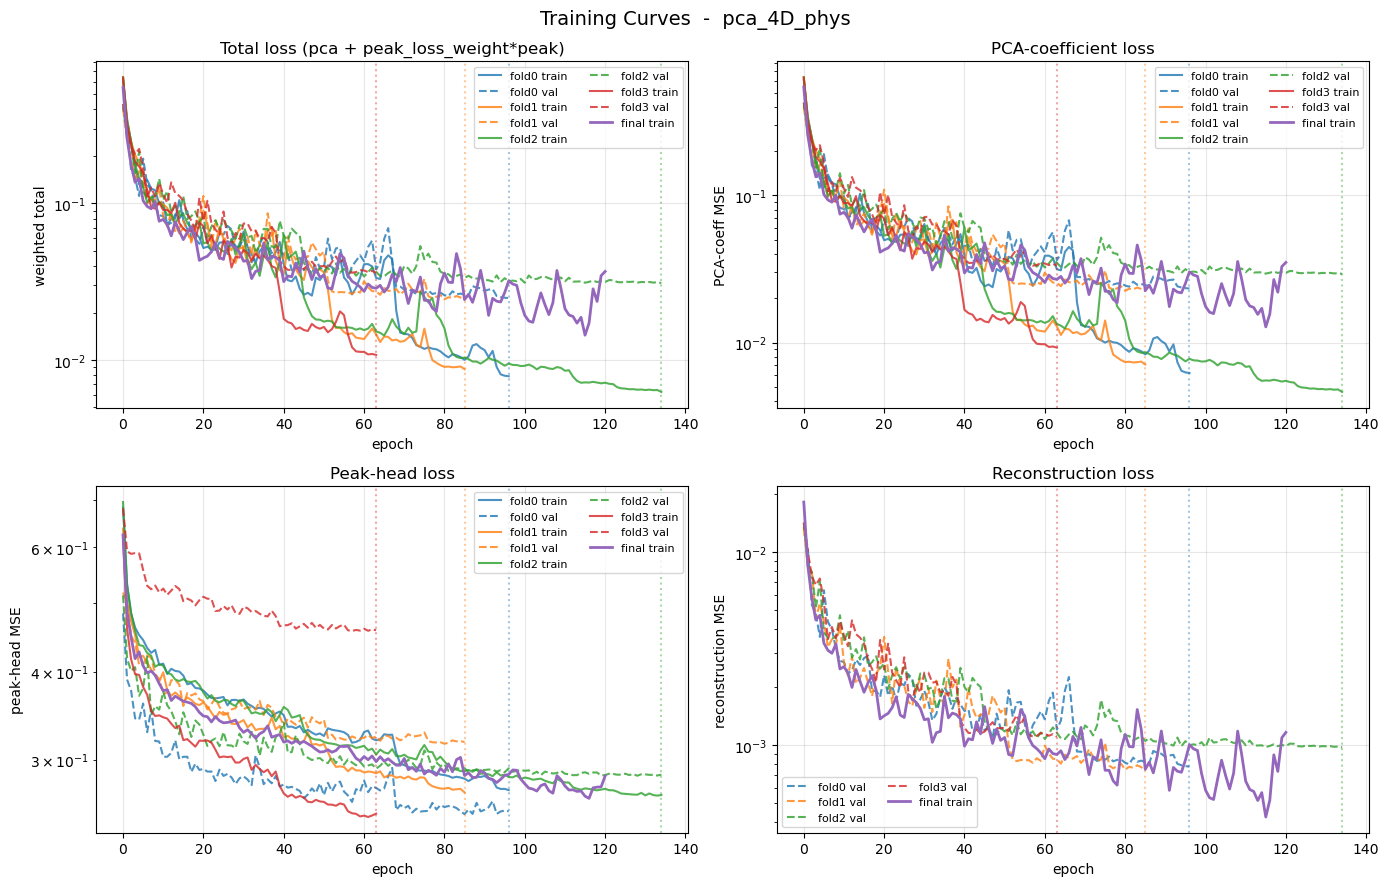

In [14]:
#### PLOT TRAINING CURVES ####
# Train/val loss vs epoch for every CV fold, plus the final-model train curve.
# Four panels: total, pca-coeff, peak, reconstruction. Folds don't log
# train_loss_recon (only val_loss_recon); the final-model trainer does.
n_folds_plot = len(fold_histories)
colors = plt.cm.tab10(np.arange(n_folds_plot + 1))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flatten()

panels = [
    ("train_loss",       "val_loss",       "weighted total",     "Total loss (pca + peak_loss_weight*peak)"),
    ("train_loss_pca",   "val_loss_pca",   "PCA-coeff MSE",      "PCA-coefficient loss"),
    ("train_loss_peak",  "val_loss_peak",  "peak-head MSE",      "Peak-head loss"),
    (None,               "val_loss_recon", "reconstruction MSE", "Reconstruction loss"),
]
final_train_keys = ["train_loss", "train_loss_pca", "train_loss_peak", "train_loss_recon"]
for ax, (tk, vk, ylabel, title), final_tk in zip(axes_flat, panels, final_train_keys):
    for i, h in enumerate(fold_histories):
        if tk is not None:
            ep = np.arange(len(h[tk]))
            ax.plot(ep, h[tk], color=colors[i], linestyle='-',  alpha=0.8, label=f'fold{i} train')
        ep_v = np.arange(len(h[vk]))
        ax.plot(ep_v, h[vk], color=colors[i], linestyle='--', alpha=0.8, label=f'fold{i} val')
        ax.axvline(h["stop_epoch"], color=colors[i], linestyle=':', alpha=0.4)
    if final_tk in final_history:
        ax.plot(
            np.arange(len(final_history[final_tk])), final_history[final_tk],
            color=colors[-1], linestyle='-', linewidth=2, label='final train'
        )
    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle(f'Training Curves  -  {NAME}', fontsize=14)
fig.tight_layout()
plt.show()

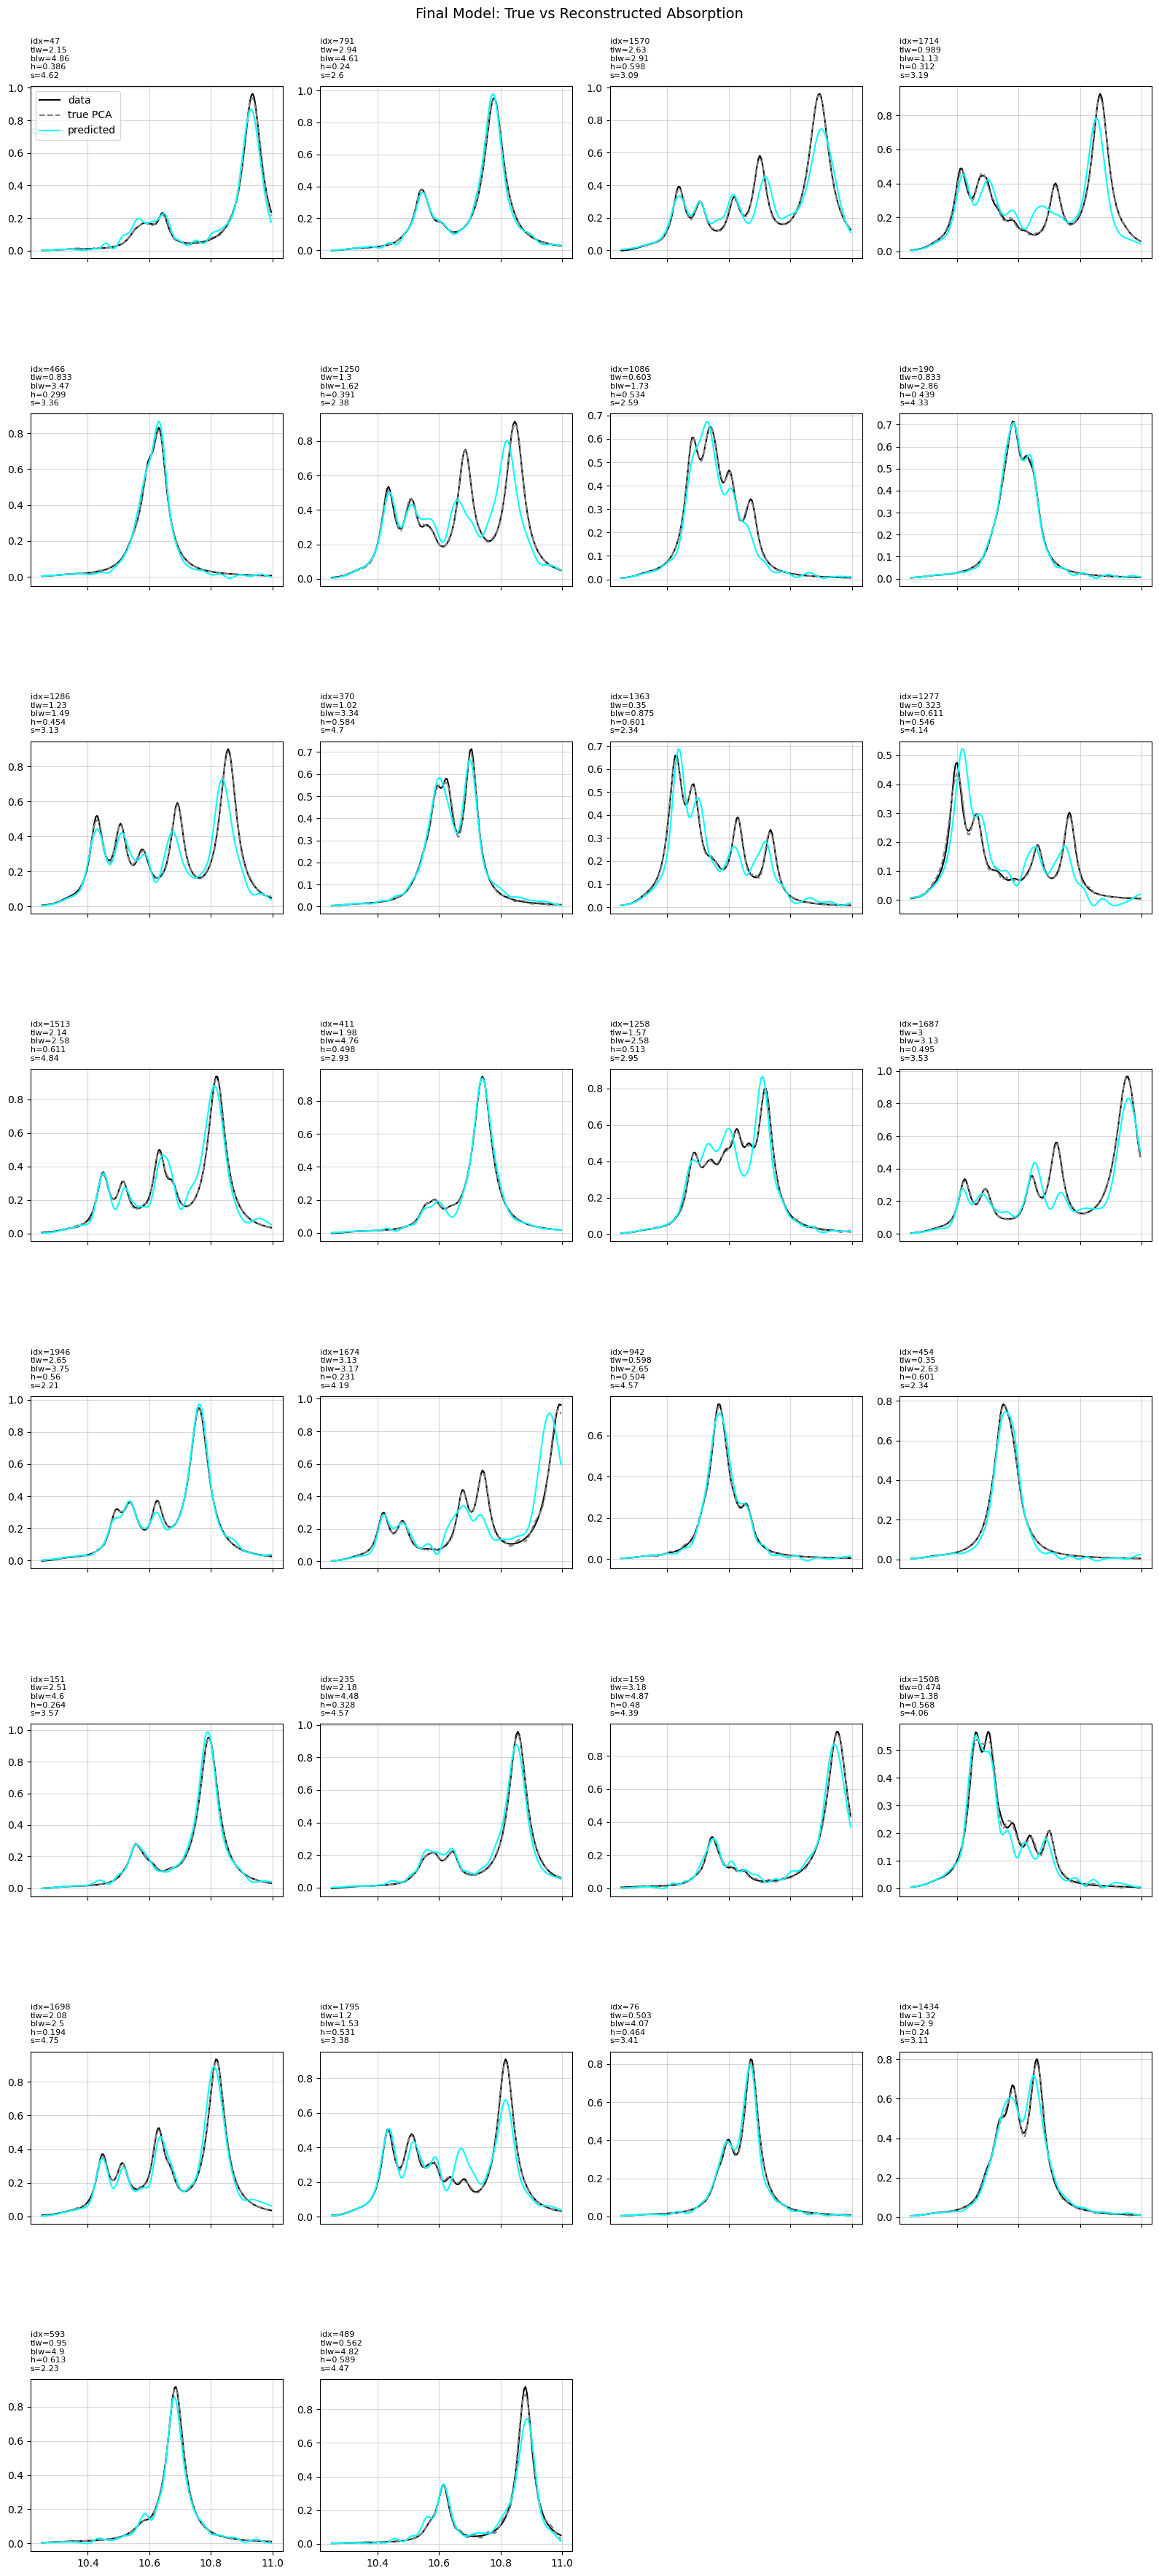

In [15]:
#### PLOT FINAL MODEL RECONSTRUCTIONS ####
plot_idx = np.asarray(test_indices)[::10]

final_model_net.eval()
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    pca_sel  = data.pca[plot_idx]
    pca_pred_sel, _ = final_model_net(geom_sel)
    pred_spec_sel = data.reconstruct_spectrum(pca_pred_sel).numpy()
    true_spec_sel = data.reconstruct_spectrum(pca_sel).numpy()
    raw_spec_sel = _raw_abs[plot_idx]

wl_plot = np.asarray(data.wl)
geom_table_sorted = pca_ft['geometry_table'].sort_index()
n_plot = len(plot_idx)
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_sel[i], color='cyan', label='predicted')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle("Final Model: True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()

#### <span style="color:cyan">**Training - Final Model (patience on train loss)**</span>

Patience | Epoch 0001 | K= 25 | lr=3.41e-03 | Loss PCA: 0.548716 | Loss Peak: 0.626362 | RECON: 1.827e-02 | patience: 0/30
Patience | Epoch 0002 | K= 25 | lr=3.41e-03 | Loss PCA: 0.252676 | Loss Peak: 0.476809 | RECON: 8.411e-03 | patience: 0/30
Patience | Epoch 0003 | K= 25 | lr=3.41e-03 | Loss PCA: 0.174606 | Loss Peak: 0.447696 | RECON: 5.812e-03 | patience: 0/30
Patience | Epoch 0004 | K= 25 | lr=3.41e-03 | Loss PCA: 0.142279 | Loss Peak: 0.420222 | RECON: 4.736e-03 | patience: 0/30
Patience | Epoch 0005 | K= 25 | lr=3.41e-03 | Loss PCA: 0.127131 | Loss Peak: 0.410980 | RECON: 4.232e-03 | patience: 0/30
Patience | Epoch 0006 | K= 25 | lr=3.41e-03 | Loss PCA: 0.108055 | Loss Peak: 0.408785 | RECON: 3.597e-03 | patience: 0/30
Patience | Epoch 0007 | K= 25 | lr=3.41e-03 | Loss PCA: 0.109827 | Loss Peak: 0.403986 | RECON: 3.656e-03 | patience: 0/30
Patience | Epoch 0008 | K= 25 | lr=3.41e-03 | Loss PCA: 0.102635 | Loss Peak: 0.393786 | RECON: 3.417e-03 | patience: 0/30
Patience | Epoch

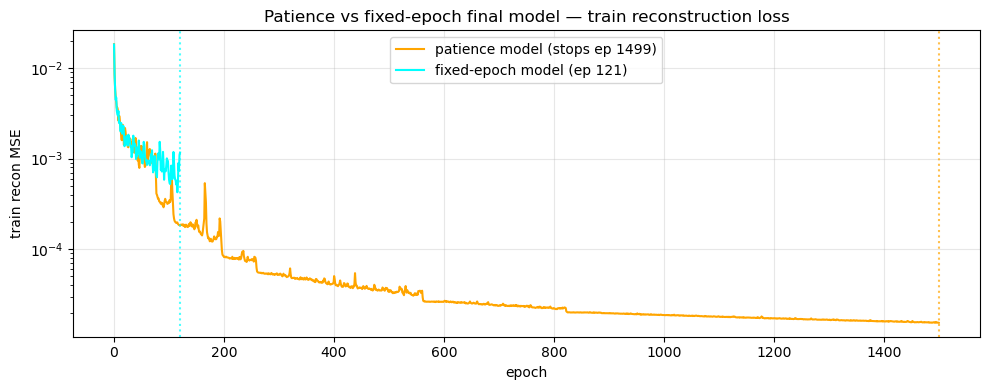

In [17]:
#### FINAL MODEL â€” PATIENCE ON TRAIN LOSS ####
# Trains on the same non-test split as the fixed-epoch model above but runs
# until the 5-epoch smoothed training loss stops improving for `patience`
# consecutive epochs, then restores the best-seen checkpoint.
os.makedirs(f'{train_config["path"]}/final_model_patience', exist_ok=True)

PATIENCE_FINAL = 30
MAX_EPOCHS_FINAL = 1500 # upper bound; patience will stop well before this

seed_everything(loader_config['seed'])
final_model_patience = PcaPeakMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    MLP_config['n_peaks'],
    input_dim=MLP_config["input_dim"]
)

_, patience_history = train_pca_regression_final_patience(
    final_model_patience,
    data,
    final_train_loader,      # same non-test loader as fixed-epoch model
    max_epochs=MAX_EPOCHS_FINAL,
    lr=train_config['lr'],
    wd=train_config['wd'],
    path=f'{train_config["path"]}/final_model_patience',
    patience=PATIENCE_FINAL,
    peak_loss_weight=train_config["peak_loss_weight"],
)

# Evaluate on held-out test set
final_model_patience.eval()
pat_coeff_sum = 0.0
pat_recon_sum = 0.0
pat_samples = 0
pat_peak_abs_errs = []
pat_peak_loc_errs = []
_mse = torch.nn.MSELoss()
with torch.no_grad():
    for geom, pca_feat, amp_feat, mask in test_loader:
        pca_pred, _ = final_model_patience(geom)
        pred_spec = data.reconstruct_spectrum(pca_pred)
        true_spec = data.reconstruct_spectrum(pca_feat)

        batch_n = geom.shape[0]
        pat_coeff_sum += _mse(pca_pred, pca_feat).item() * batch_n
        pat_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        pat_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        pat_peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        pat_peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

pat_coeff_mse = pat_coeff_sum / max(pat_samples, 1)
pat_recon_mse = pat_recon_sum / max(pat_samples, 1)
pat_peak_mae  = torch.cat(pat_peak_abs_errs).mean().item()
pat_peak_loc  = torch.cat(pat_peak_loc_errs).mean().item()

patience_metrics = {
    "test_coeff_mse":    float(pat_coeff_mse),
    "test_coeff_rmse":   float(math.sqrt(pat_coeff_mse)),
    "test_recon_mse":    float(pat_recon_mse),
    "test_recon_rmse":   float(math.sqrt(pat_recon_mse)),
    "peak_mae":          float(pat_peak_mae),
    "peak_loc_error_um": float(pat_peak_loc),
    "stop_epoch":        int(patience_history["stop_epoch"]),
    "epochs_trained":    int(len(patience_history["train_loss"])),
    "n_train":           int(len(non_test_idx)),
    "n_test":            int(len(test_indices)),
}

pm_w = max(len(k) for k in patience_metrics) + 2
print(f"\n{'='*72}")
print(f"Final Model â€” patience={PATIENCE_FINAL} on train loss")
print(f"{'='*72}")
for k, v in patience_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{pm_w}} {fmt}")
print("=" * 72)

# Compare directly against fixed-epoch model
print(f"\n{'--- vs fixed-epoch model ---':^72}")
print(f"  recon MSE:  patience={pat_recon_mse:.6f}   fixed={final_metrics['test_recon_mse']:.6f}   "
      f"delta={pat_recon_mse - final_metrics['test_recon_mse']:+.6f}")
print(f"  peak loc:   patience={pat_peak_loc*1e3:.3f} nm   fixed={final_metrics['peak_loc_error_um']*1e3:.3f} nm")
print(f"  stop epoch: patience={patience_metrics['stop_epoch']}   fixed={final_epochs}")

# Plot train loss curve vs fixed-epoch
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(patience_history["train_loss_recon"], color='orange', label=f'patience model (stops ep {patience_metrics["stop_epoch"]})')
ax.plot(final_history["train_loss_recon"],    color='cyan',   label=f'fixed-epoch model (ep {final_epochs})')
ax.axvline(patience_metrics["stop_epoch"], color='orange', linestyle=':', alpha=0.7)
ax.axvline(final_epochs - 1,               color='cyan',   linestyle=':', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.set_ylabel('train recon MSE')
ax.set_title('Patience vs fixed-epoch final model â€” train reconstruction loss')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

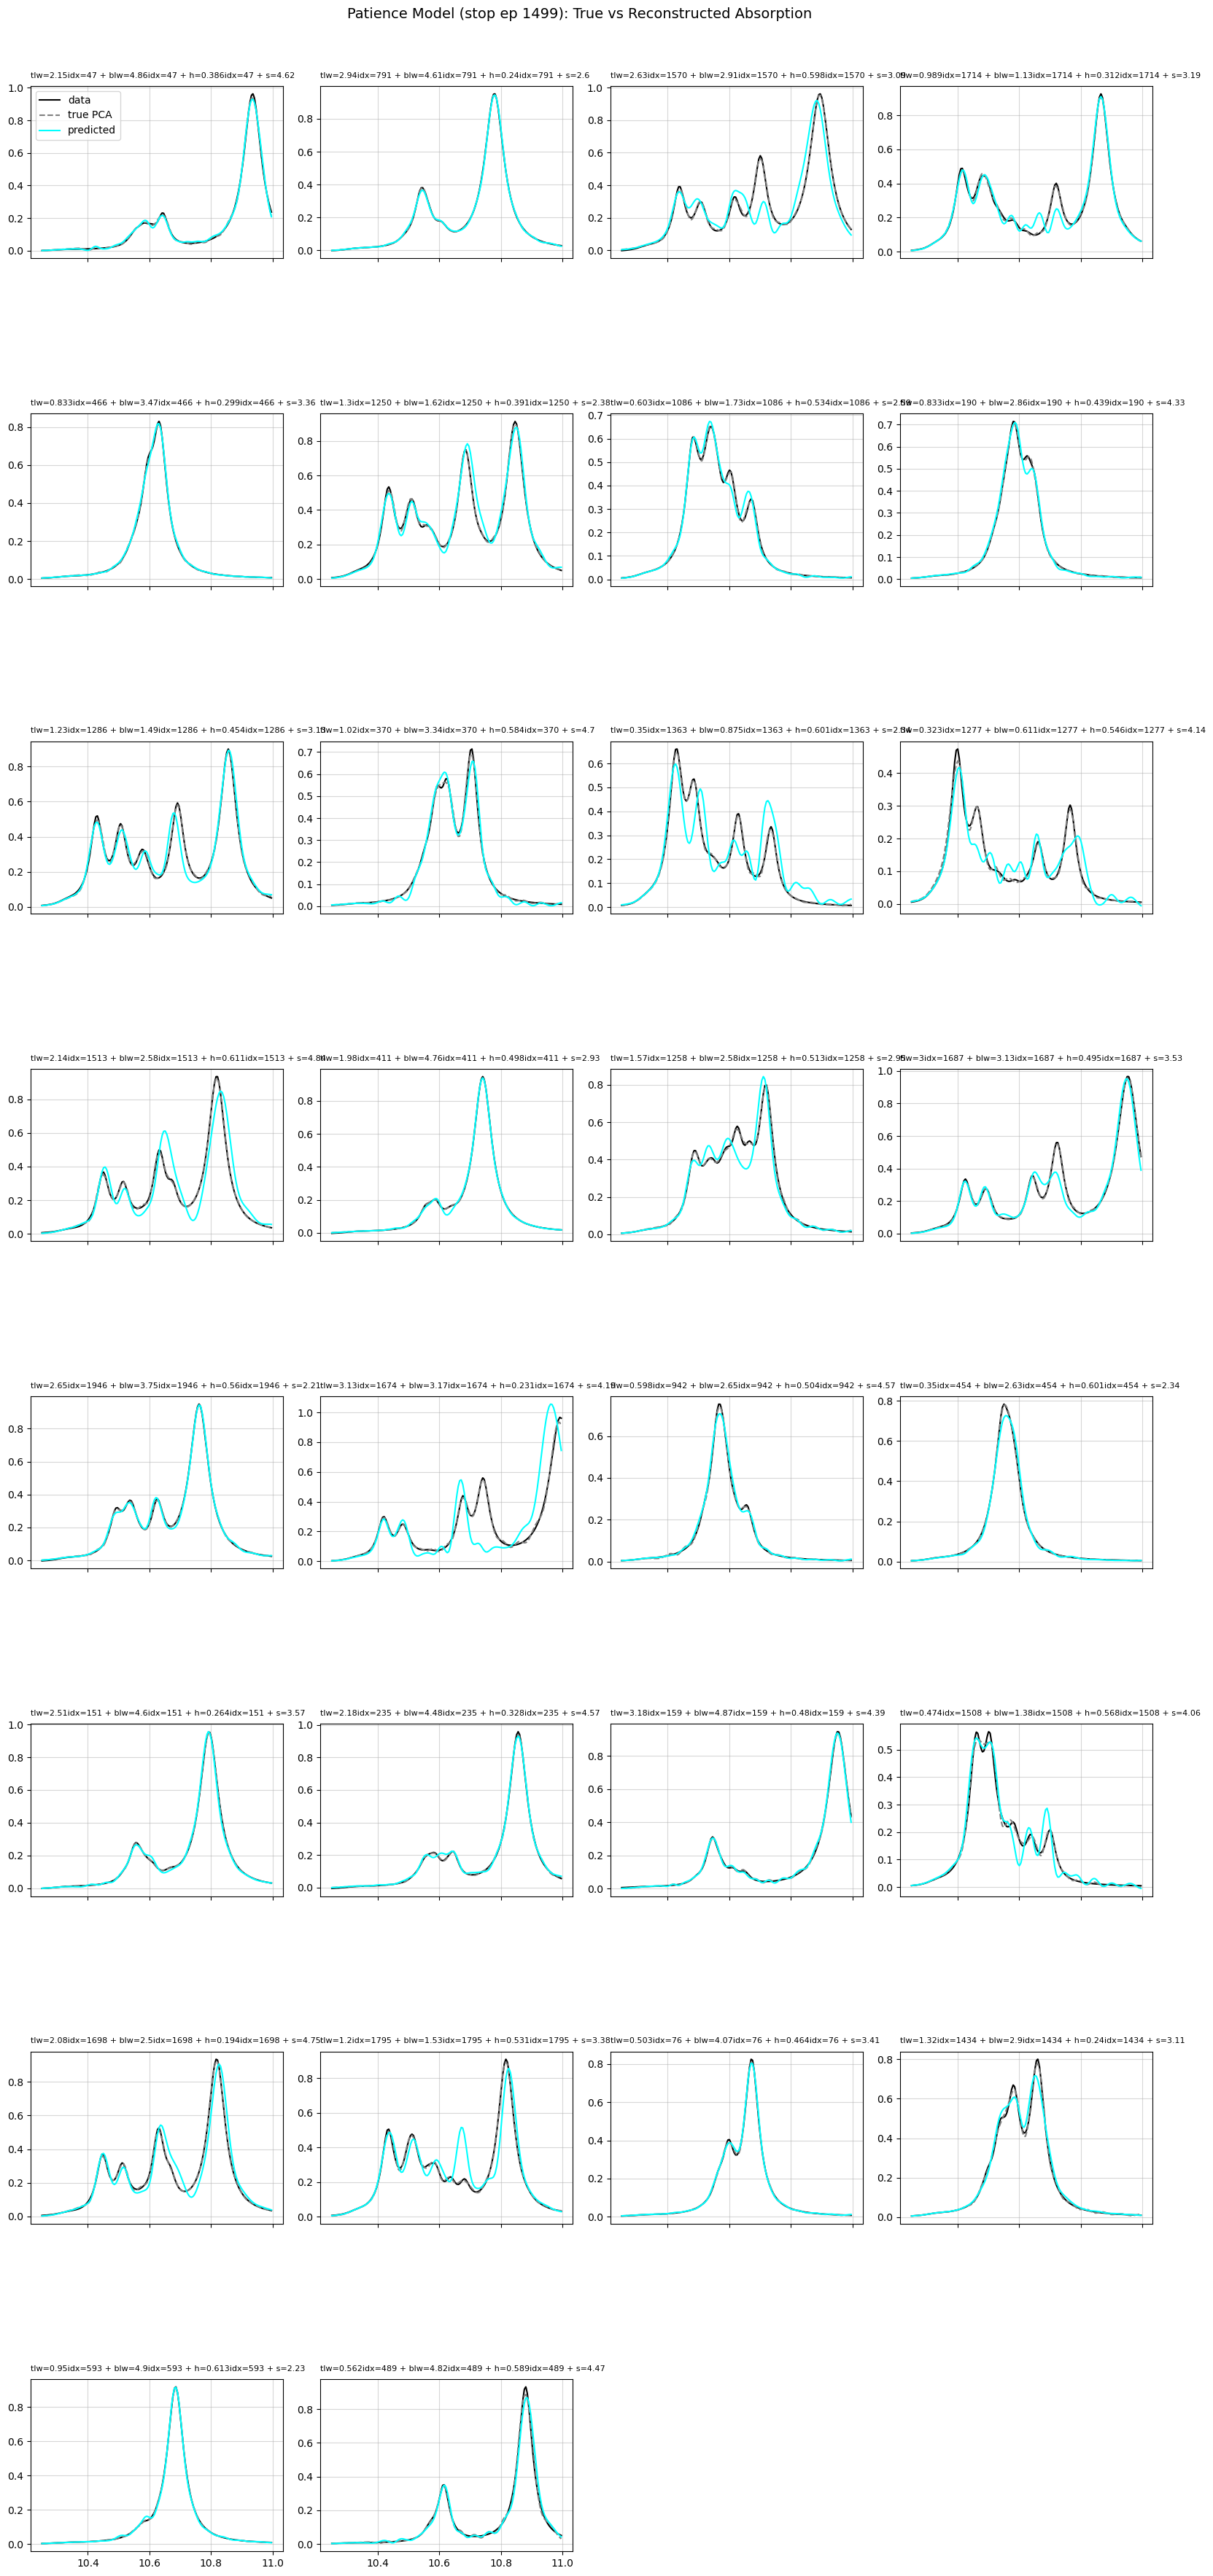

In [19]:
#### PLOT PATIENCE MODEL RECONSTRUCTIONS ####
final_model_patience.eval()
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    pca_sel  = data.pca[plot_idx]
    pca_pred_sel, _ = final_model_patience(geom_sel)
    pred_spec_sel = data.reconstruct_spectrum(pca_pred_sel).numpy()
    true_spec_sel = data.reconstruct_spectrum(pca_sel).numpy()
    raw_spec_sel = _raw_abs[plot_idx]

n_plot = len(plot_idx)
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color="k", label="data")
    ax.plot(wl_plot, true_spec_sel[i], color="grey", linestyle="--", label="true PCA")
    ax.plot(wl_plot, pred_spec_sel[i], color="cyan", label="predicted")
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)} + ".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc="left", pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis("off")
fig.suptitle(f"Patience Model (stop ep {patience_metrics['stop_epoch']}): True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()

#### <span style="color:cyan">**Training - Final Model (ensemble)**</span>

In [20]:
#### ENSEMBLE (FOLD MODELS) ####
n_folds = loader_config['splits']
fold_models = []
for i in range(n_folds):
    ckpt = torch.load(
        f'{train_config["path"]}/fold{i}/best_pca_peak.pt',
        weights_only=False
    )
    m = PcaPeakMLP(
        MLP_config['k'],
        MLP_config['hidden_dim'],
        MLP_config['n_layers'],
        MLP_config['p'],
        MLP_config['n_peaks'],
        input_dim=MLP_config['input_dim']
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    fold_models.append(m)

# Evaluate ensemble on test set
ens_coeff_sum = 0.0
ens_recon_sum = 0.0
ens_samples = 0
ens_peak_abs_errs = []
ens_peak_loc_errs = []
pca_pred_std_list  = []
_mse = torch.nn.MSELoss()

with torch.no_grad():
    for geom, pca_feat, amp_feat, mask in test_loader:
        pca_stack = torch.stack([m(geom)[0] for m in fold_models])  # (n_folds, batch, K)
        ens_pca   = pca_stack.mean(dim=0)

        pca_pred_std_list.append(pca_stack.std(dim=0).mean(dim=1))

        pred_spec = data.reconstruct_spectrum(ens_pca)
        true_spec = data.reconstruct_spectrum(pca_feat)

        batch_n = geom.shape[0]
        ens_coeff_sum += _mse(ens_pca, pca_feat).item() * batch_n
        ens_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        ens_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        ens_peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        ens_peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

ens_coeff_mse = ens_coeff_sum / max(ens_samples, 1)
ens_recon_mse = ens_recon_sum / max(ens_samples, 1)
ens_peak_mae  = torch.cat(ens_peak_abs_errs).mean().item()
ens_peak_loc  = torch.cat(ens_peak_loc_errs).mean().item()

pca_spread_all = torch.cat(pca_pred_std_list)

ensemble_metrics = {
    "test_coeff_mse":    float(ens_coeff_mse),
    "test_coeff_rmse":   float(math.sqrt(ens_coeff_mse)),
    "test_recon_mse":    float(ens_recon_mse),
    "test_recon_rmse":   float(math.sqrt(ens_recon_mse)),
    "peak_mae":          float(ens_peak_mae),
    "peak_loc_error_um": float(ens_peak_loc),
    "pca_pred_std_mean": float(pca_spread_all.mean().item()),
    "pca_pred_std_std":  float(pca_spread_all.std().item()),
    "n_models":          n_folds,
    "n_test":            int(ens_samples),
}

em_w = max(len(k) for k in ensemble_metrics) + 2
print(f"\n{'='*72}")
print(f"Ensemble ({n_folds} fold models, evaluated once on test)")
print(f"{'='*72}")
for k, v in ensemble_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{em_w}} {fmt}")
print("=" * 72)

kfold_results['ensemble'] = ensemble_metrics
with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


Ensemble (4 fold models, evaluated once on test)
test_coeff_mse          0.026445
test_coeff_rmse         0.162619
test_recon_mse       0.000880326
test_recon_rmse        0.0296703
peak_mae               0.0226617
peak_loc_error_um     0.00576952
pca_pred_std_mean      0.0666448
pca_pred_std_std        0.044339
n_models                       4
n_test                       292


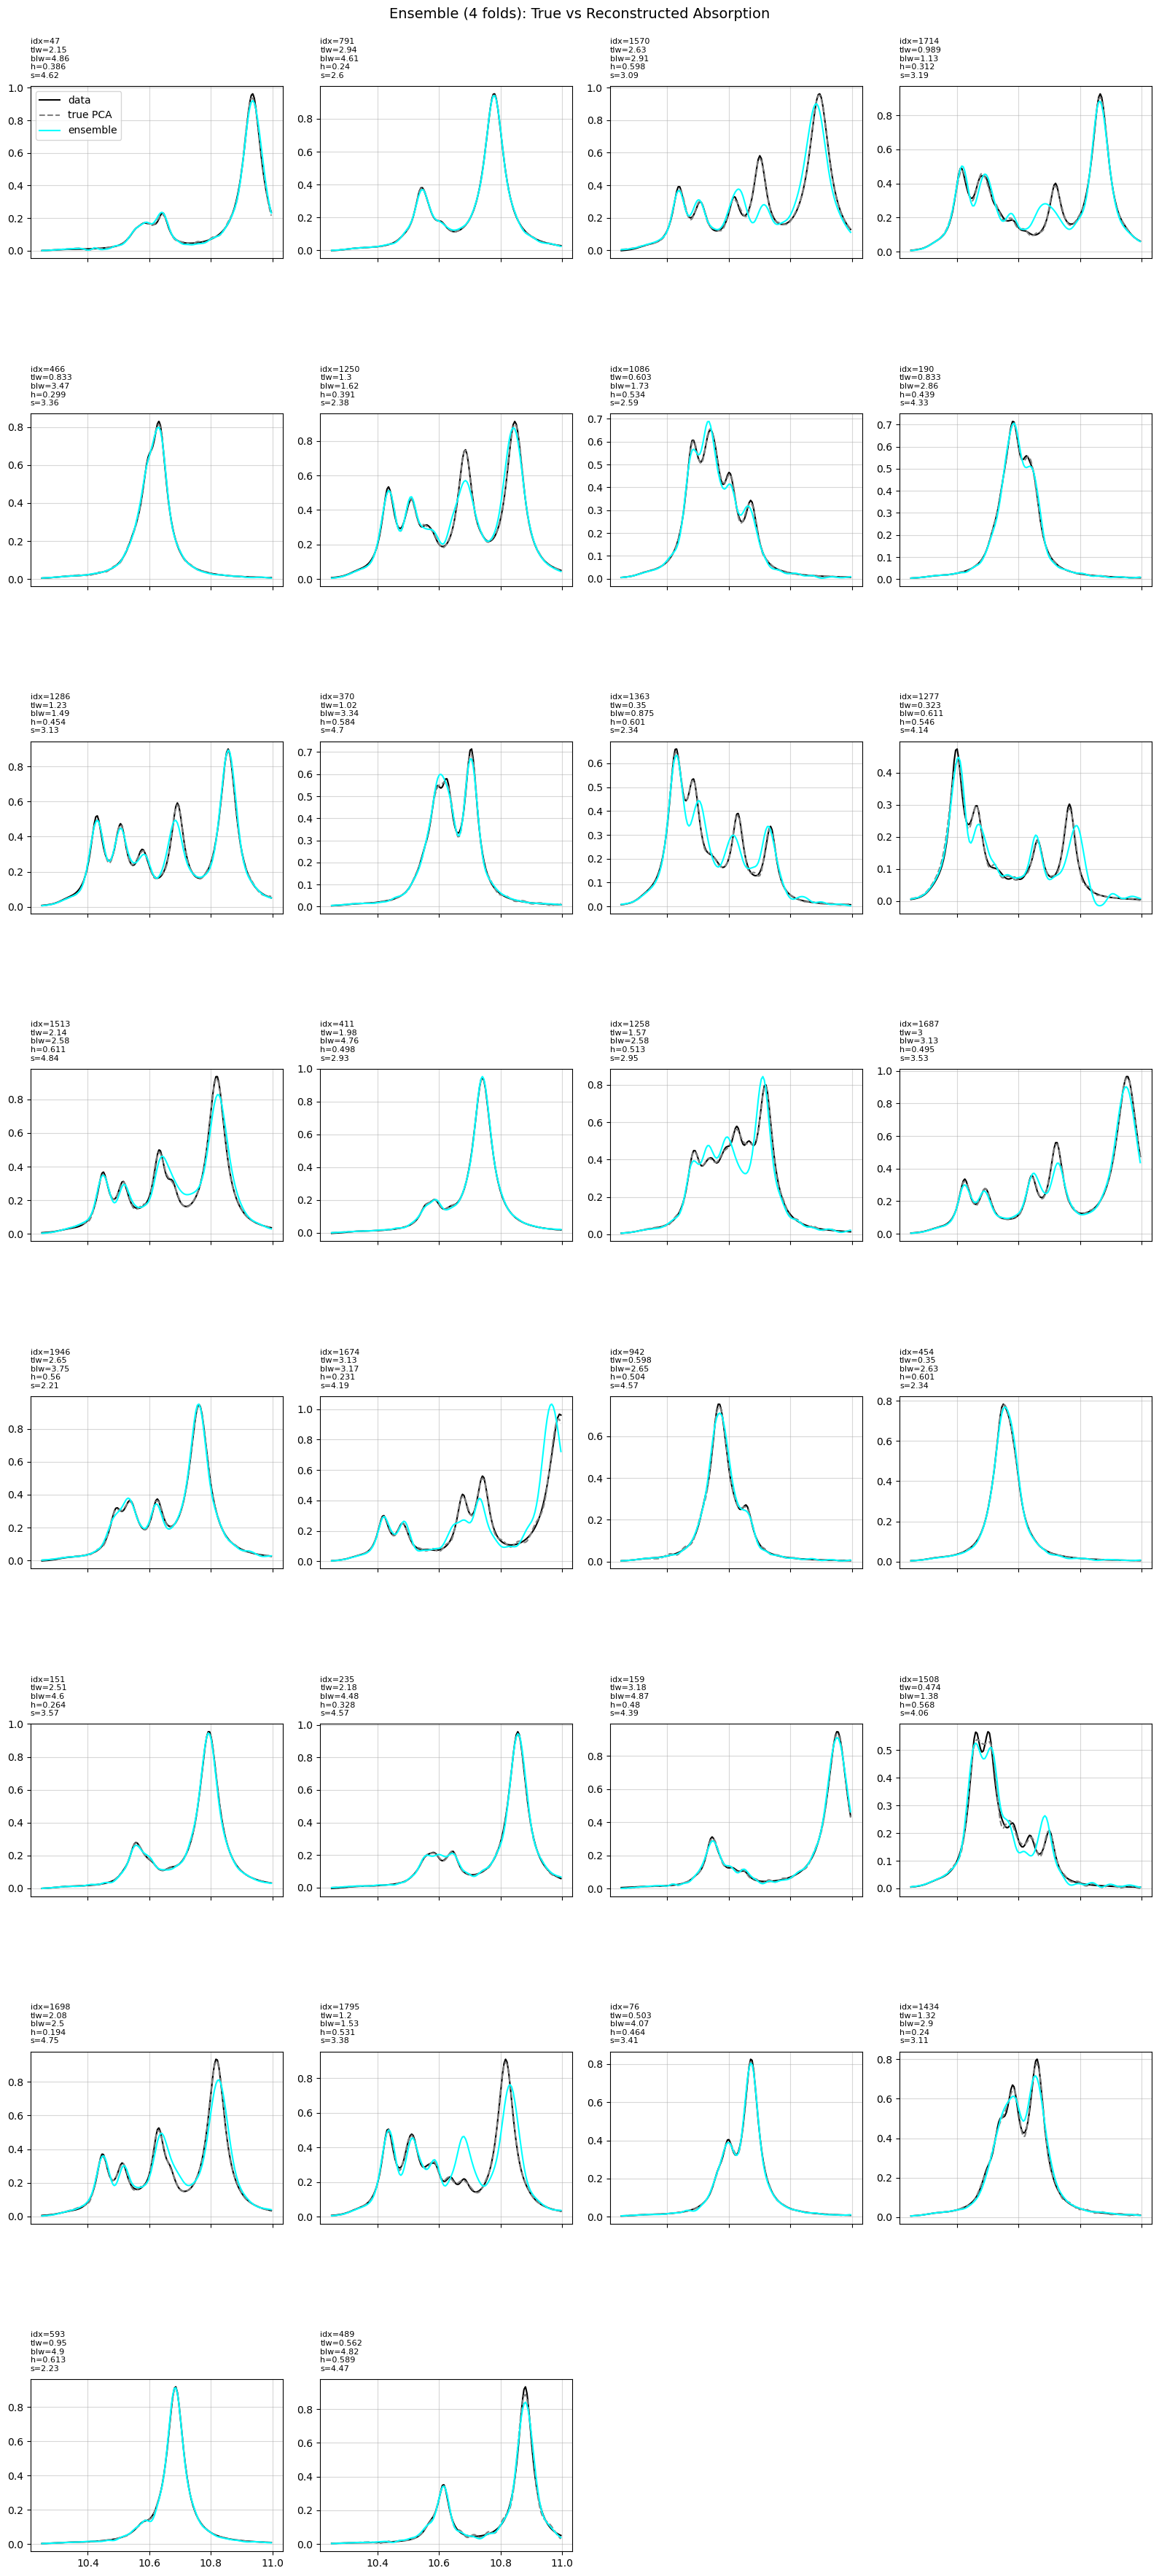

In [21]:
#### PLOT ENSEMBLE RECONSTRUCTIONS ####
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    pca_sel  = data.pca[plot_idx]
    ens_pca_sel = torch.stack([m(geom_sel)[0] for m in fold_models]).mean(dim=0)
    ens_spec_sel = data.reconstruct_spectrum(ens_pca_sel).numpy()

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, ens_spec_sel[i], color='cyan', label='ensemble')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f"Ensemble ({n_folds} folds): True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()

#### <span style="color:cyan">**Diagnostics - Error vs Geometry**</span>

In [15]:
#### PER-SAMPLE TEST DIAGNOSTICS ####
from scipy.stats import pearsonr, spearmanr

test_idx_arr = np.asarray(test_indices)

with torch.no_grad():
    geom_t = data.geom[test_idx_arr]
    feat_t = data.pca[test_idx_arr]
    ens_pred_t = torch.stack([m(geom_t)[0] for m in fold_models]).mean(dim=0)
    coeff_rmse_per_sample = ((ens_pred_t - feat_t) ** 2).mean(dim=1).sqrt().numpy()
    pred_spec_t = data.reconstruct_spectrum(ens_pred_t)
    true_spec_t = data.reconstruct_spectrum(feat_t)
    recon_rmse_per_sample = ((pred_spec_t - true_spec_t) ** 2).mean(dim=1).sqrt().numpy()

geom_table_sorted = pca_ft['geometry_table'].sort_index()
geom_test = geom_table_sorted.iloc[test_idx_arr].reset_index(drop=True)
diag_test = pd.DataFrame({
    'coeff_rmse': coeff_rmse_per_sample,
    'recon_rmse': recon_rmse_per_sample,
    'size':       (geom_test['tlw'] + geom_test['blw']).values / 2.0,
    'ratio':      (geom_test['blw'] / geom_test['tlw']).values,
    'tlw':        geom_test['tlw'].values,
    'blw':        geom_test['blw'].values,
})
print(diag_test.describe().round(4))

       coeff_rmse  recon_rmse      size     ratio       tlw       blw
count    292.0000    292.0000  292.0000  292.0000  292.0000  292.0000
mean       0.1137      0.0208    2.3123    2.9493    1.4318    3.1928
std        0.1167      0.0213    0.7894    2.2011    0.7695    1.1366
min        0.0152      0.0028    0.3760    1.0134    0.2730    0.4790
25%        0.0409      0.0075    1.7394    1.5249    0.8020    2.4110
50%        0.0664      0.0121    2.3728    2.2382    1.2652    3.2525
75%        0.1399      0.0255    2.9230    3.5423    1.9923    4.1560
max        0.7617      0.1390    4.0291   13.9525    3.2050    4.9927


(TLW+BLW)/2   Pearson r=-0.323 (p=1.63e-08)   Spearman rho=-0.370 (p=6.66e-11)
BLW/TLW       Pearson r=-0.409 (p=3.14e-13)   Spearman rho=-0.670 (p=1.79e-39)


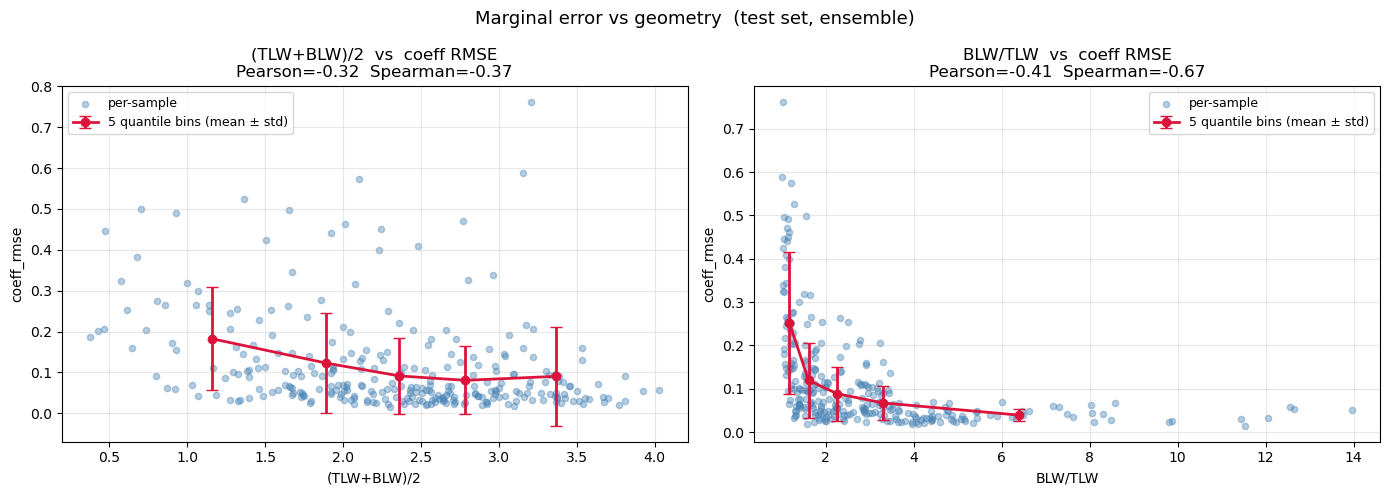

In [16]:
#### MARGINAL: CORRELATION + BINNED RMSE ####
metrics = [('size', '(TLW+BLW)/2'), ('ratio', 'BLW/TLW')]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, metrics):
    x = diag_test[col].values
    y = diag_test['coeff_rmse'].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    print(f"{label:12s}  Pearson r={pr:+.3f} (p={pp:.2e})   "
          f"Spearman rho={sr:+.3f} (p={sp:.2e})")

    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue', label='per-sample')

    n_bins = 5
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bin_id = np.digitize(x, edges[1:-1])
    centers, means, stds = [], [], []
    for b in range(n_bins):
        sel = bin_id == b
        if sel.any():
            centers.append(x[sel].mean())
            means.append(y[sel].mean())
            stds.append(y[sel].std())
    centers, means, stds = map(np.asarray, (centers, means, stds))
    ax.errorbar(centers, means, yerr=stds, color='crimson', marker='o',
                linewidth=2, capsize=4, label=f'{n_bins} quantile bins (mean Â± std)')

    ax.set_xlabel(label)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{label}  vs  coeff RMSE\nPearson={pr:+.2f}  Spearman={sr:+.2f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Marginal error vs geometry  (test set, ensemble)', fontsize=13)
fig.tight_layout()
plt.show()

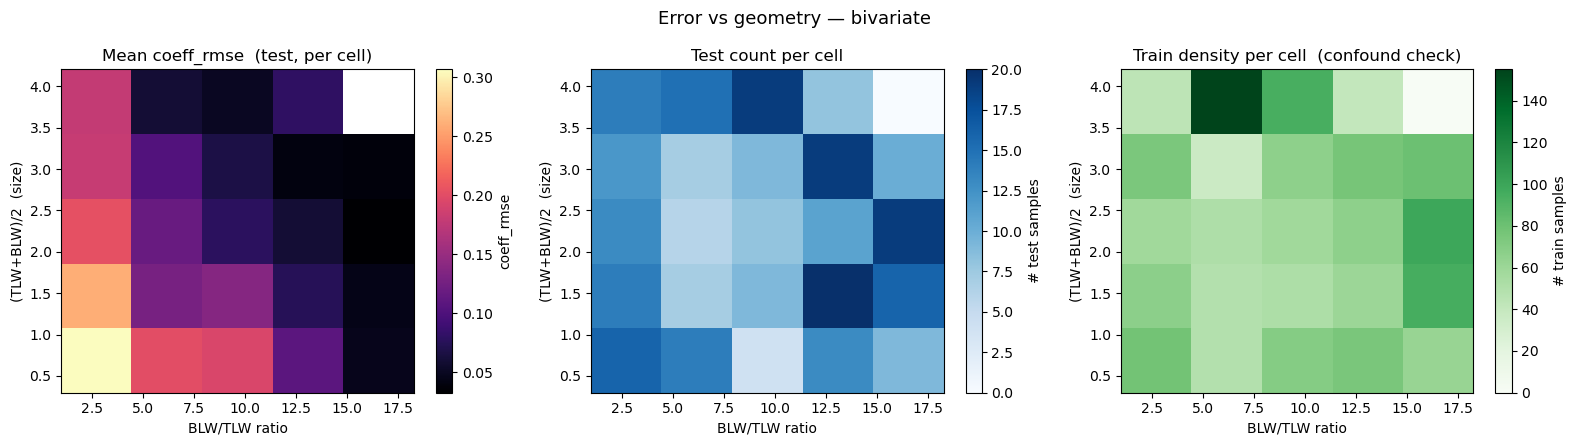


Cells with high error (>= 0.1795) AND low train density (<= 51 samples): 1 / 25


In [17]:
#### 2D: MEAN ERROR HEATMAP + TRAIN-DENSITY CONFOUND CHECK ####
geom_train = geom_table_sorted.iloc[non_test_idx].reset_index(drop=True)
size_train  = ((geom_train['tlw'] + geom_train['blw']) / 2.0).values
ratio_train = (geom_train['blw'] / geom_train['tlw']).values

n_bins = 5
size_edges  = np.quantile(np.concatenate([diag_test['size'].values,  size_train]),
                          np.linspace(0, 1, n_bins + 1))
ratio_edges = np.quantile(np.concatenate([diag_test['ratio'].values, ratio_train]),
                          np.linspace(0, 1, n_bins + 1))
size_edges[-1]  += 1e-9
ratio_edges[-1] += 1e-9

err_sum, _, _    = np.histogram2d(diag_test['size'].values, diag_test['ratio'].values,
                                  bins=[size_edges, ratio_edges],
                                  weights=diag_test['coeff_rmse'].values)
test_count, _, _ = np.histogram2d(diag_test['size'].values, diag_test['ratio'].values,
                                  bins=[size_edges, ratio_edges])
mean_err = np.where(test_count > 0, err_sum / np.maximum(test_count, 1), np.nan)

train_density, _, _ = np.histogram2d(size_train, ratio_train,
                                     bins=[size_edges, ratio_edges])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
extent = [ratio_edges[0], ratio_edges[-1], size_edges[0], size_edges[-1]]

im0 = axes[0].imshow(mean_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[0].set_title('Mean coeff_rmse  (test, per cell)')
fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

im1 = axes[1].imshow(test_count, origin='lower', aspect='auto', extent=extent, cmap='Blues')
axes[1].set_title('Test count per cell')
fig.colorbar(im1, ax=axes[1], label='# test samples')

im2 = axes[2].imshow(train_density, origin='lower', aspect='auto', extent=extent, cmap='Greens')
axes[2].set_title('Train density per cell  (confound check)')
fig.colorbar(im2, ax=axes[2], label='# train samples')

for ax in axes:
    ax.set_xlabel('BLW/TLW ratio')
    ax.set_ylabel('(TLW+BLW)/2  (size)')

fig.suptitle('Error vs geometry â€” bivariate', fontsize=13)
fig.tight_layout()
plt.show()

flat_err     = mean_err[~np.isnan(mean_err)]
err_thresh   = np.quantile(flat_err, 0.75) if flat_err.size else np.nan
train_thresh = np.quantile(train_density, 0.25)
high_err_low_data = (mean_err >= err_thresh) & (train_density <= train_thresh)
print(f"\nCells with high error (>= {err_thresh:.4f}) AND low train density "
      f"(<= {train_thresh:.0f} samples): "
      f"{int(np.nansum(high_err_low_data))} / {mean_err.size}")

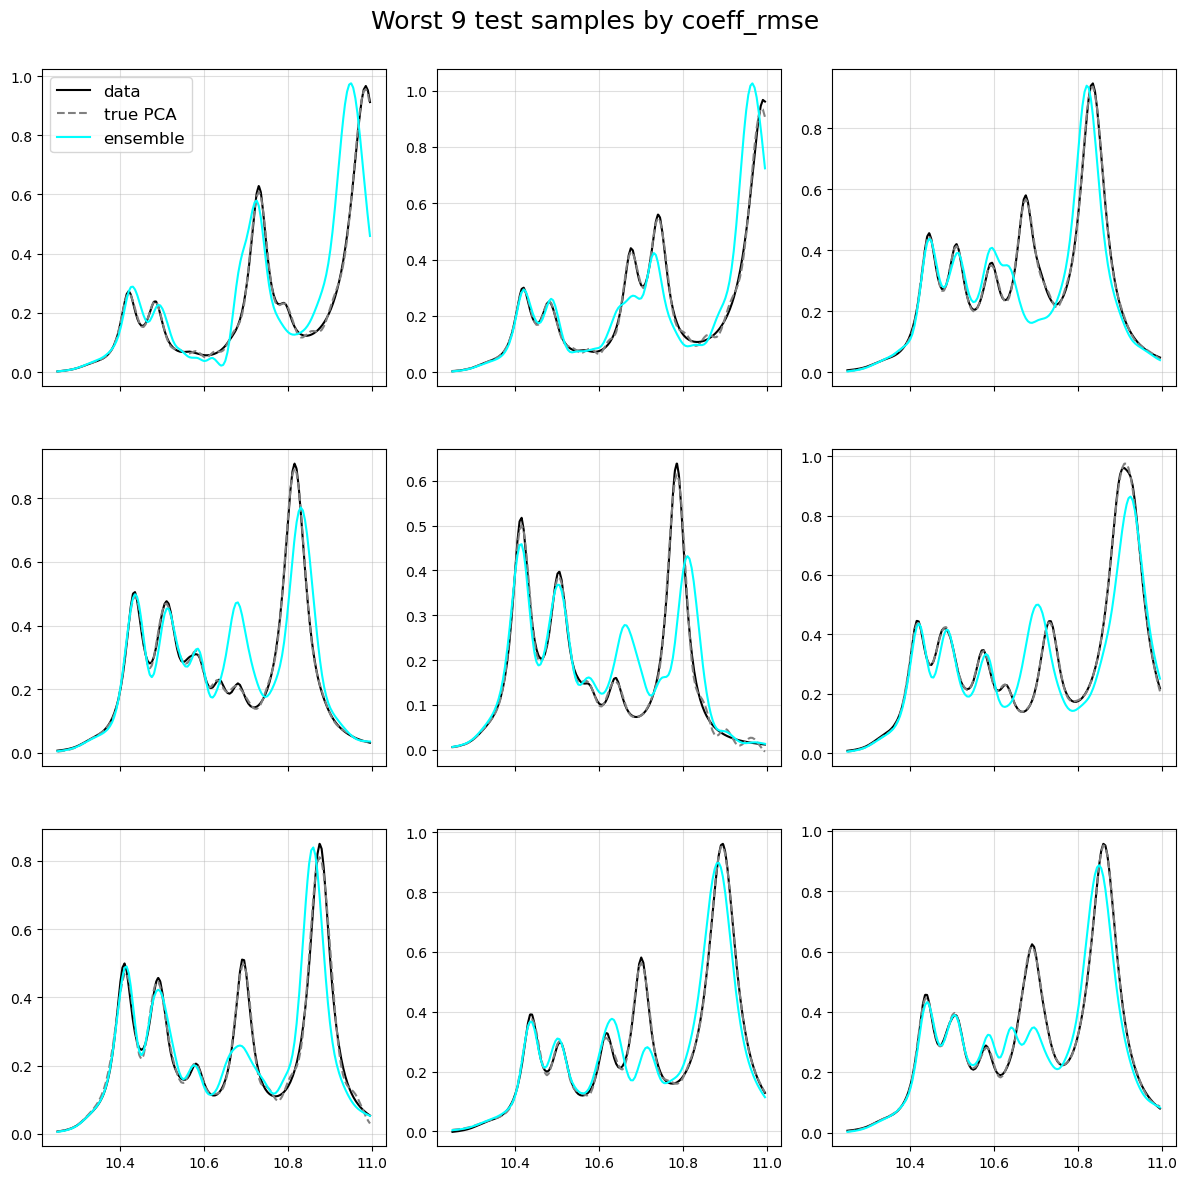

In [33]:
#### WORST-N SPECTRA GRID ####
N_WORST = 9
worst_local  = np.argsort(diag_test['coeff_rmse'].values)[::-1][:N_WORST]
worst_global = test_idx_arr[worst_local]

with torch.no_grad():
    geom_w = data.geom[worst_global]
    feat_w = data.pca[worst_global]
    ens_coeffs_w = torch.stack([m(geom_w)[0] for m in fold_models]).mean(dim=0)
    pred_spec_w = data.reconstruct_spectrum(ens_coeffs_w).numpy()
    true_spec_w = data.reconstruct_spectrum(feat_w).numpy()
raw_spec_w = _raw_abs[worst_global]

wl_plot = np.asarray(data.wl)
ncols_w = 3
nrows_w = (N_WORST + ncols_w - 1) // ncols_w
fig, axes = plt.subplots(nrows_w, ncols_w, figsize=(4 * ncols_w, 4 * nrows_w), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, (li, gi) in enumerate(zip(worst_local, worst_global)):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_w[i],  color='k',    label='data')
    ax.plot(wl_plot, true_spec_w[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_w[i], color='cyan', label='ensemble')
    ax.grid(alpha=0.4)
    if i == 0:
        ax.legend(fontsize=12)
for j in range(N_WORST, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f'Worst {N_WORST} test samples by coeff_rmse', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.93, hspace=0.2)
plt.show()

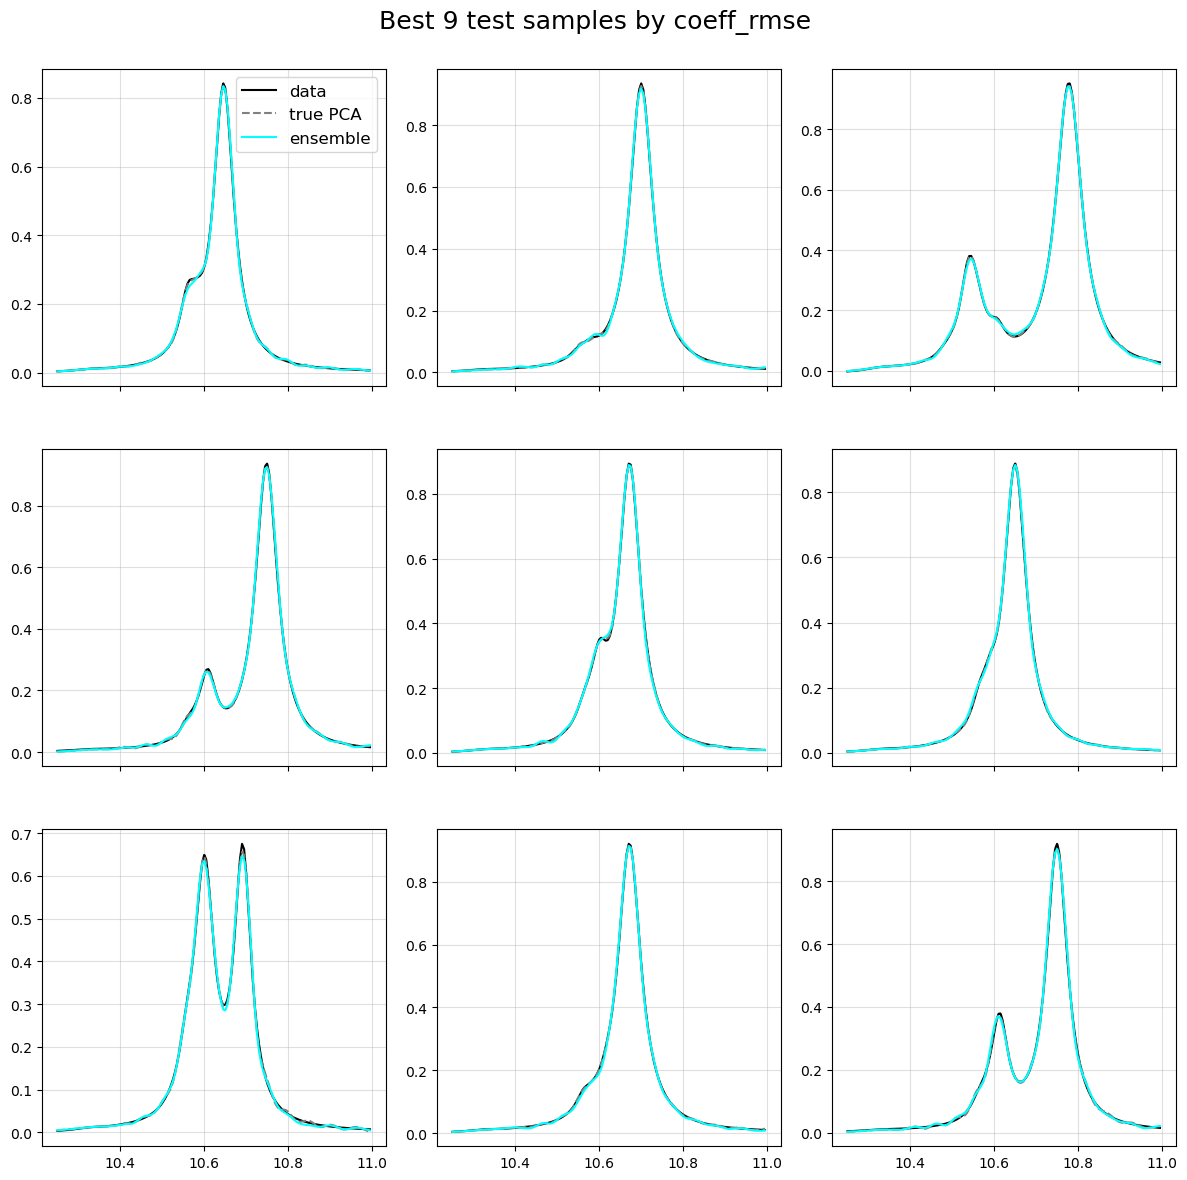

In [34]:
#### BEST-N SPECTRA GRID ####
N_BEST = 9
best_local  = np.argsort(diag_test['coeff_rmse'].values)[:N_BEST]
best_global = test_idx_arr[best_local]

with torch.no_grad():
    geom_b = data.geom[best_global]
    feat_b = data.pca[best_global]
    ens_coeffs_b = torch.stack([m(geom_b)[0] for m in fold_models]).mean(dim=0)
    pred_spec_b = data.reconstruct_spectrum(ens_coeffs_b).numpy()
    true_spec_b = data.reconstruct_spectrum(feat_b).numpy()
raw_spec_b = _raw_abs[best_global]

ncols_b = 3
nrows_b = (N_BEST + ncols_b - 1) // ncols_b
fig, axes = plt.subplots(nrows_b, ncols_b, figsize=(4 * ncols_b, 4 * nrows_b), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, (li, gi) in enumerate(zip(best_local, best_global)):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_b[i],  color='k',    label='data')
    ax.plot(wl_plot, true_spec_b[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_b[i], color='cyan', label='ensemble')
    ax.grid(alpha=0.4)
    if i == 0:
        ax.legend(fontsize=12)
for j in range(N_BEST, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f'Best {N_BEST} test samples by coeff_rmse', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.93, hspace=0.2)
plt.show()

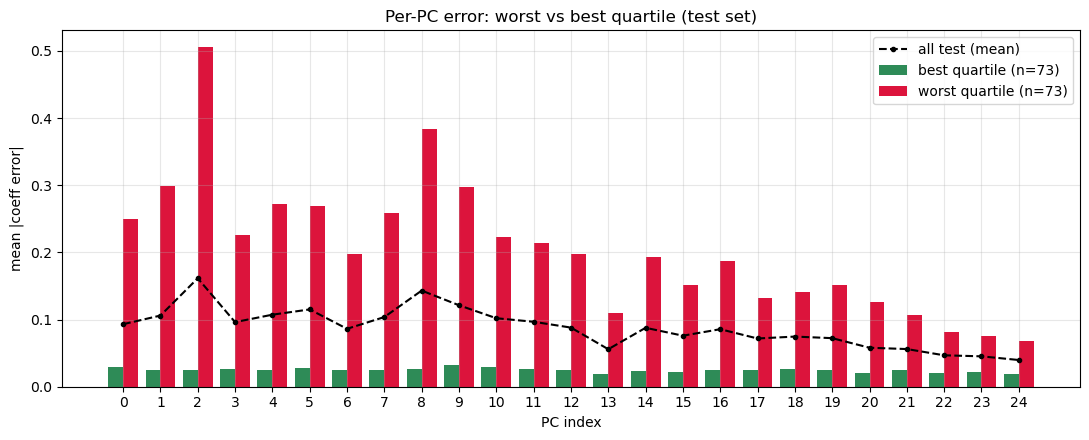


Worst/best |error| ratio by PC (top 5 most-amplified):
  PC02:  best=0.0250   worst=0.5052   ratio=20.22x
  PC08:  best=0.0258   worst=0.3837   ratio=14.86x
  PC01:  best=0.0251   worst=0.2986   ratio=11.89x
  PC04:  best=0.0252   worst=0.2722   ratio=10.81x
  PC07:  best=0.0256   worst=0.2586   ratio=10.11x


In [35]:
#### PER-PC ERROR BREAKDOWN ####
coeff_resid = (ens_pred_t - feat_t).abs().numpy()  # (N_test, K)
rmse_arr = diag_test['coeff_rmse'].values

q25, q75 = np.quantile(rmse_arr, [0.25, 0.75])
best_mask  = rmse_arr <= q25
worst_mask = rmse_arr >= q75

mean_best  = coeff_resid[best_mask].mean(axis=0)
mean_worst = coeff_resid[worst_mask].mean(axis=0)
mean_all   = coeff_resid.mean(axis=0)

K_pc = coeff_resid.shape[1]
pcs = np.arange(K_pc)

fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.4
ax.bar(pcs - w/2, mean_best,  width=w, color='seagreen', label=f'best quartile (n={best_mask.sum()})')
ax.bar(pcs + w/2, mean_worst, width=w, color='crimson',  label=f'worst quartile (n={worst_mask.sum()})')
ax.plot(pcs, mean_all, color='k', linestyle='--', marker='.', label='all test (mean)')
ax.set_xlabel('PC index')
ax.set_ylabel('mean |coeff error|')
ax.set_title('Per-PC error: worst vs best quartile (test set)')
ax.set_xticks(pcs)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

ratio_per_pc = mean_worst / np.maximum(mean_best, 1e-12)
print("\nWorst/best |error| ratio by PC (top 5 most-amplified):")
order = np.argsort(ratio_per_pc)[::-1][:5]
for pc in order:
    print(f"  PC{pc:02d}:  best={mean_best[pc]:.4f}   worst={mean_worst[pc]:.4f}   "
          f"ratio={ratio_per_pc[pc]:.2f}x")

Per-geometry-param correlations (test set, ensemble):
  tlw       Pearson r=+0.141 (p=1.63e-02)   Spearman rho=+0.165 (p=4.64e-03)
  blw       Pearson r=-0.544 (p=7.26e-24)   Spearman rho=-0.644 (p=1.31e-35)
  h         Pearson r=-0.078 (p=1.83e-01)   Spearman rho=-0.054 (p=3.53e-01)
  s         Pearson r=-0.035 (p=5.55e-01)   Spearman rho=+0.023 (p=6.93e-01)


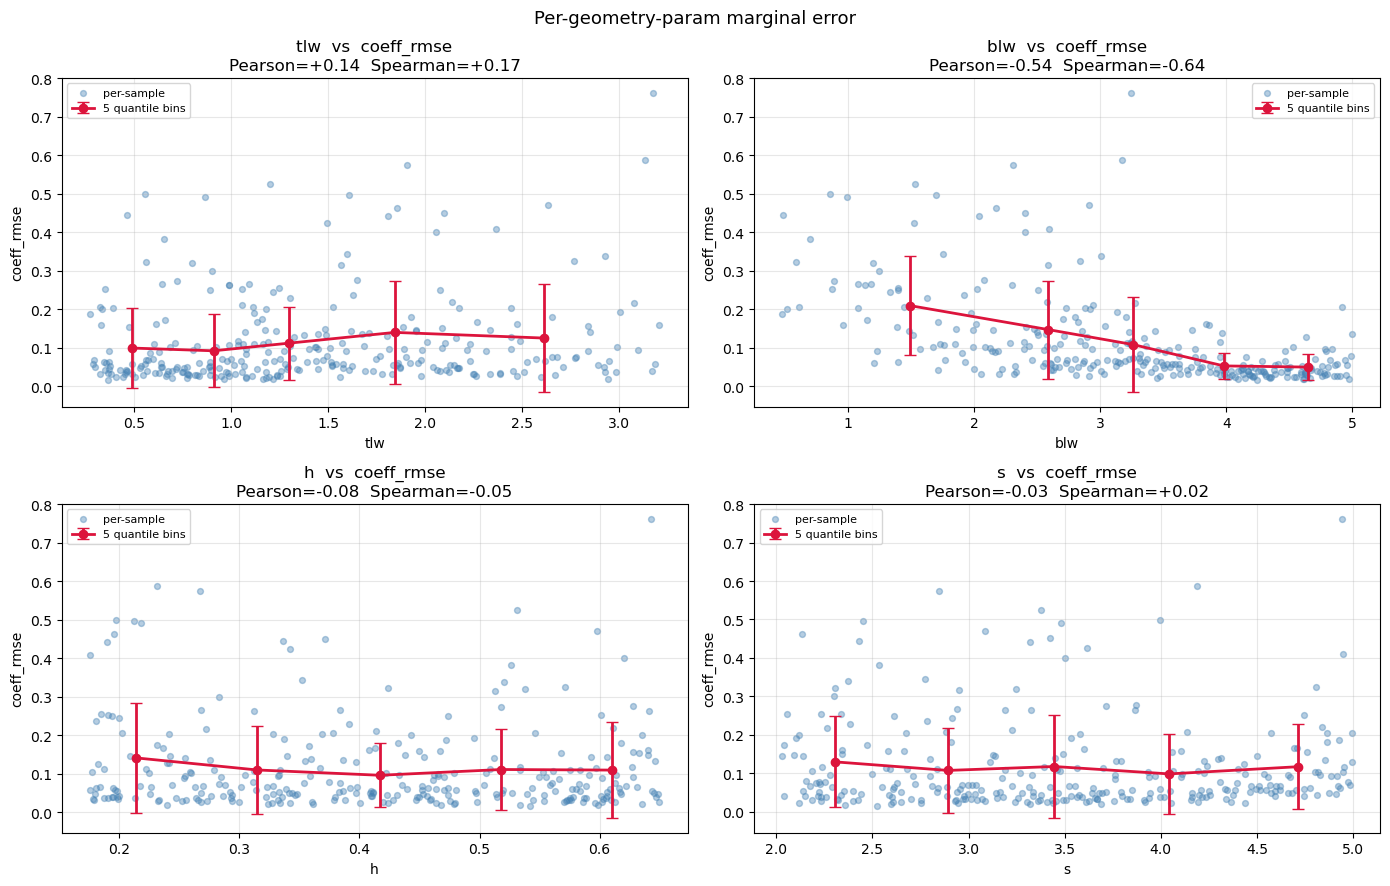

In [36]:
#### RESIDUAL VS EACH GEOMETRY PARAMETER ####
geom_cols = list(geom_table_sorted.columns)
ncols_g = 2
nrows_g = (len(geom_cols) + ncols_g - 1) // ncols_g
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(7 * ncols_g, 4.5 * nrows_g))
axes_flat = np.atleast_1d(axes).flatten()

print("Per-geometry-param correlations (test set, ensemble):")
for ax, col in zip(axes_flat, geom_cols):
    x = geom_test[col].values
    y = diag_test['coeff_rmse'].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    print(f"  {col:<8}  Pearson r={pr:+.3f} (p={pp:.2e})   "
          f"Spearman rho={sr:+.3f} (p={sp:.2e})")

    ax.scatter(x, y, alpha=0.4, s=18, color='steelblue', label='per-sample')

    n_bins = 5
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bin_id = np.digitize(x, edges[1:-1])
    centers, means, stds = [], [], []
    for b in range(n_bins):
        m = bin_id == b
        if m.any():
            centers.append(x[m].mean()); means.append(y[m].mean()); stds.append(y[m].std())
    centers, means, stds = map(np.asarray, (centers, means, stds))
    ax.errorbar(centers, means, yerr=stds, color='crimson', marker='o',
                linewidth=2, capsize=4, label=f'{n_bins} quantile bins')

    ax.set_xlabel(col)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{col}  vs  coeff_rmse\nPearson={pr:+.2f}  Spearman={sr:+.2f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for j in range(len(geom_cols), len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle('Per-geometry-param marginal error', fontsize=13)
fig.tight_layout()
plt.show()

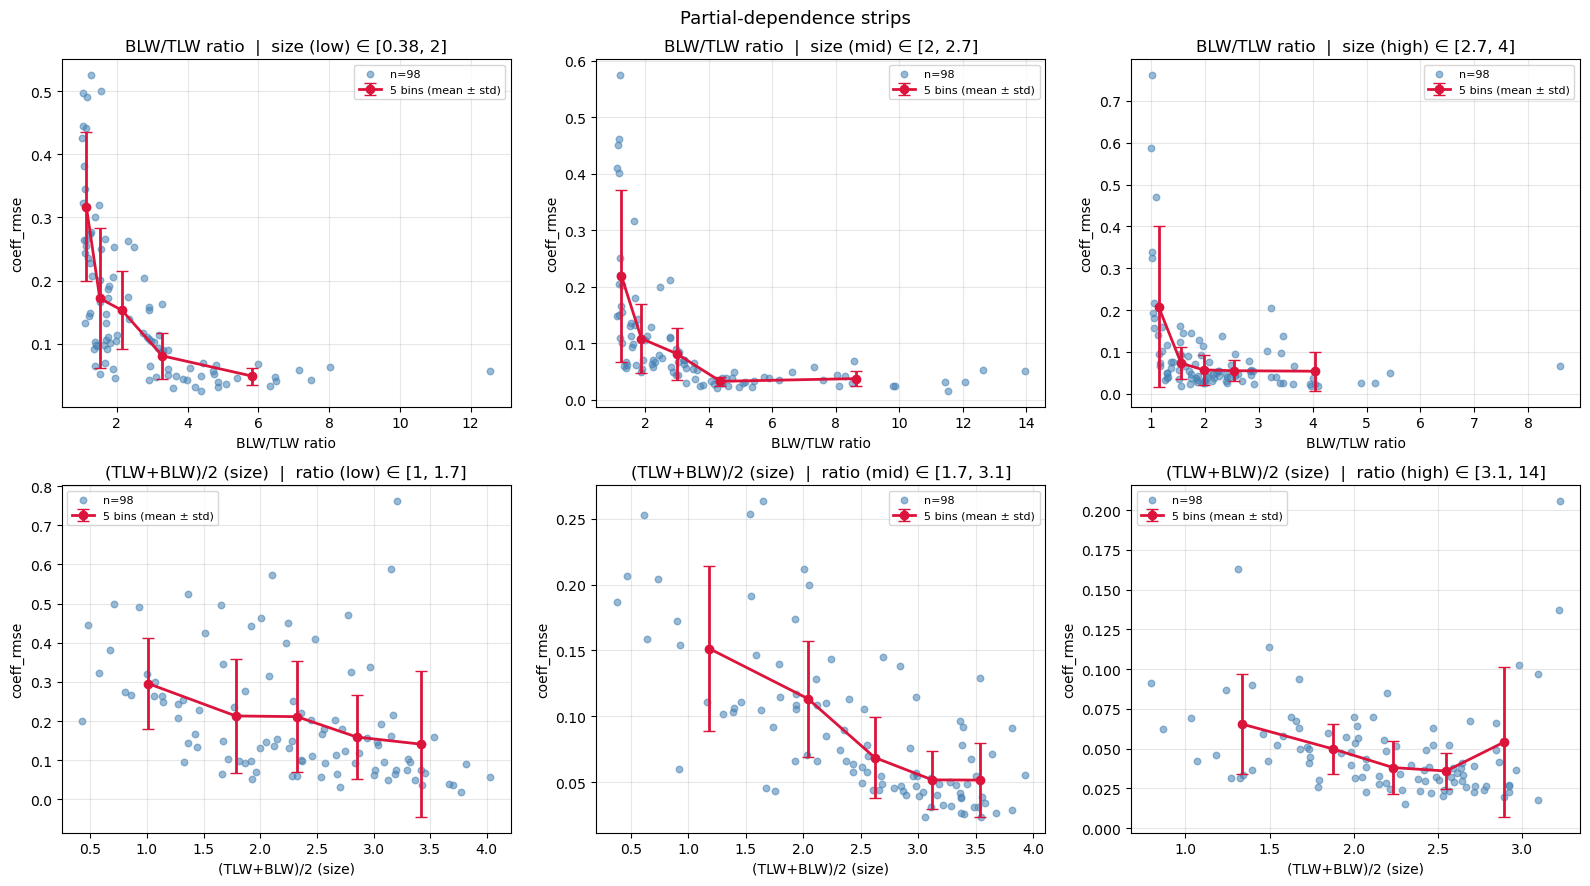

In [37]:
#### PARTIAL-DEPENDENCE STRIPS ####
def _strip(ax, x_full, y_full, hold_full, hold_lo, hold_hi, x_label, hold_label):
    sel = (hold_full >= hold_lo) & (hold_full <= hold_hi)
    if sel.sum() < 5:
        ax.set_visible(False)
        return
    x = x_full[sel]; y = y_full[sel]
    ax.scatter(x, y, alpha=0.55, s=22, color='steelblue', label=f'n={sel.sum()}')

    n_bins = min(5, max(2, sel.sum() // 8))
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bid = np.digitize(x, edges[1:-1])
    cs, ms, ss = [], [], []
    for b in range(n_bins):
        m = bid == b
        if m.any():
            cs.append(x[m].mean()); ms.append(y[m].mean()); ss.append(y[m].std())
    ax.errorbar(cs, ms, yerr=ss, color='crimson', marker='o', linewidth=2, capsize=4,
                label=f'{n_bins} bins (mean Â± std)')
    ax.set_xlabel(x_label)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{x_label}  |  {hold_label} âˆˆ [{hold_lo:.2g}, {hold_hi:.2g}]')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

size_arr  = diag_test['size'].values
ratio_arr = diag_test['ratio'].values
y_arr     = diag_test['coeff_rmse'].values

size_terc  = np.quantile(size_arr,  [0, 1/3, 2/3, 1])
ratio_terc = np.quantile(ratio_arr, [0, 1/3, 2/3, 1])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
band_names = ['low', 'mid', 'high']
for j, name in enumerate(band_names):
    _strip(axes[0, j], ratio_arr, y_arr, size_arr,
           size_terc[j],  size_terc[j+1],
           x_label='BLW/TLW ratio', hold_label=f'size ({name})')
    _strip(axes[1, j], size_arr, y_arr, ratio_arr,
           ratio_terc[j], ratio_terc[j+1],
           x_label='(TLW+BLW)/2 (size)', hold_label=f'ratio ({name})')
fig.suptitle('Partial-dependence strips', fontsize=13)
fig.tight_layout()
plt.show()

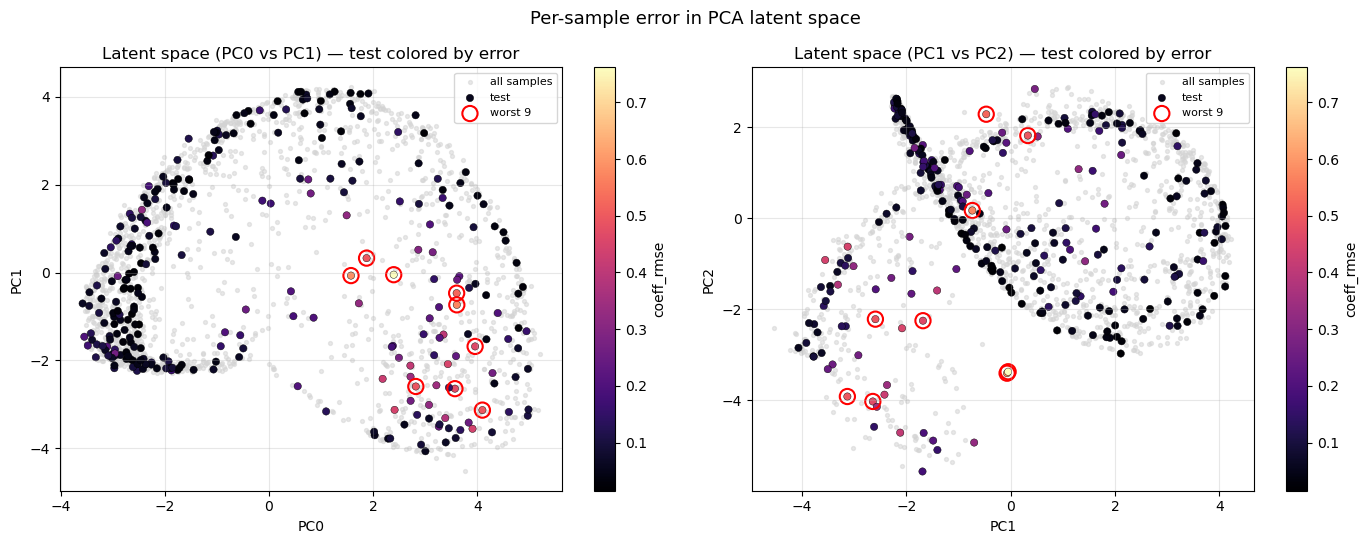

In [38]:
#### LATENT-SPACE ERROR OVERLAY ####
all_feat = data.pca.numpy()
test_feat = all_feat[test_idx_arr]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    ax.scatter(all_feat[:, i], all_feat[:, j], s=8, color='lightgrey',
               alpha=0.5, label='all samples')
    sc = ax.scatter(test_feat[:, i], test_feat[:, j],
                    c=diag_test['coeff_rmse'].values,
                    cmap='magma', s=28, edgecolor='k', linewidth=0.3, label='test')
    ax.scatter(test_feat[worst_local, i], test_feat[worst_local, j],
               s=120, facecolors='none', edgecolor='red', linewidth=1.5,
               label=f'worst {N_WORST}')
    fig.colorbar(sc, ax=ax, label='coeff_rmse')
    ax.set_xlabel(f'PC{i}')
    ax.set_ylabel(f'PC{j}')
    ax.set_title(f'Latent space (PC{i} vs PC{j}) â€” test colored by error')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Per-sample error in PCA latent space', fontsize=13)
fig.tight_layout()
plt.show()

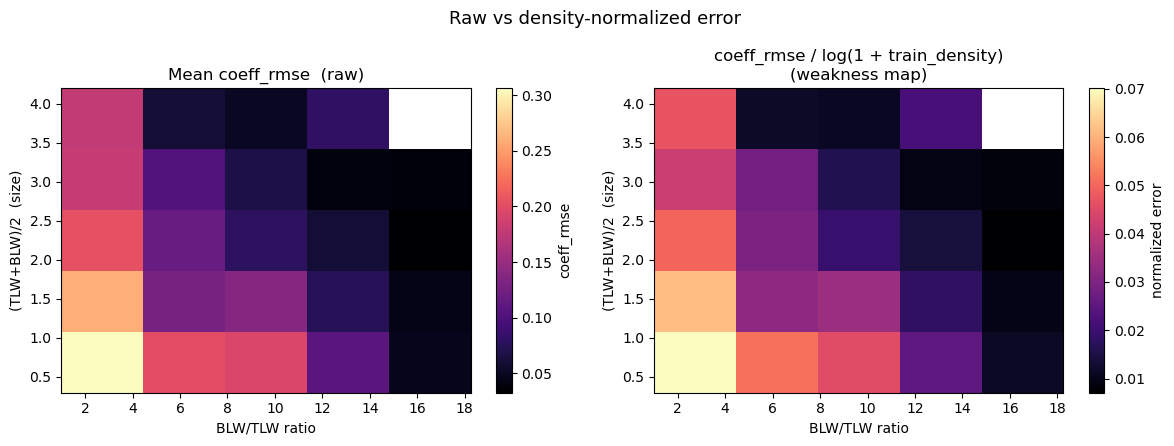

In [39]:
#### TRAIN-DENSITY-NORMALIZED ERROR HEATMAP ####
# mean coeff_rmse / log(1 + train_density) per (size, ratio) cell. Highlights
# cells where error is high *given* training coverage â€” closer to a true
# "model weakness" signal than raw mean error.
norm_err = mean_err / np.log1p(train_density)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
extent = [ratio_edges[0], ratio_edges[-1], size_edges[0], size_edges[-1]]

im0 = axes[0].imshow(mean_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[0].set_title('Mean coeff_rmse  (raw)')
fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

im1 = axes[1].imshow(norm_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[1].set_title('coeff_rmse / log(1 + train_density)\n(weakness map)')
fig.colorbar(im1, ax=axes[1], label='normalized error')

for ax in axes:
    ax.set_xlabel('BLW/TLW ratio')
    ax.set_ylabel('(TLW+BLW)/2  (size)')

fig.suptitle('Raw vs density-normalized error', fontsize=13)
fig.tight_layout()
plt.show()

C:\Users\robert\AppData\Local\Temp\ipykernel_6028\3531645535.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


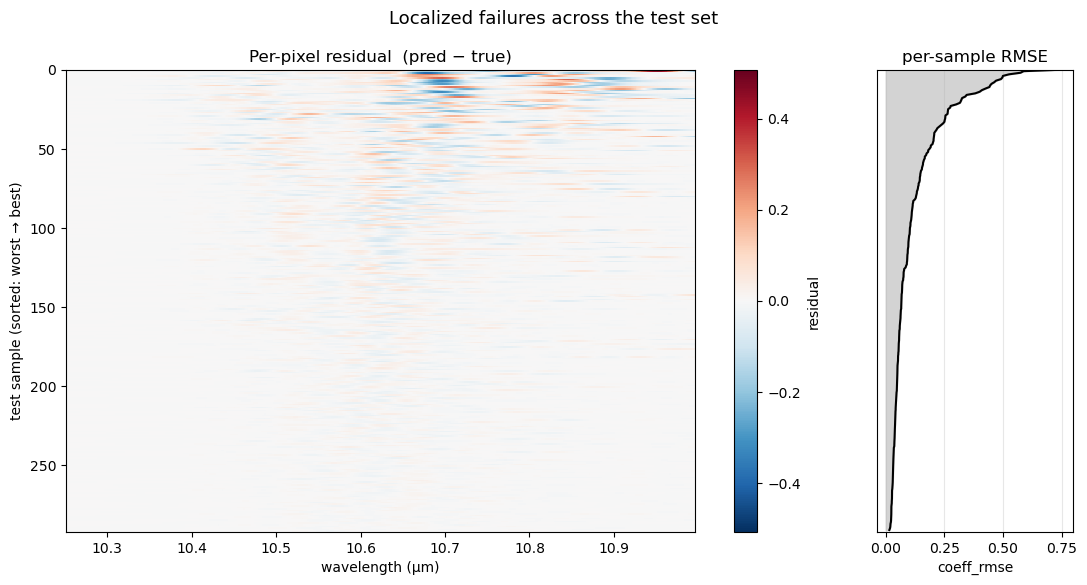

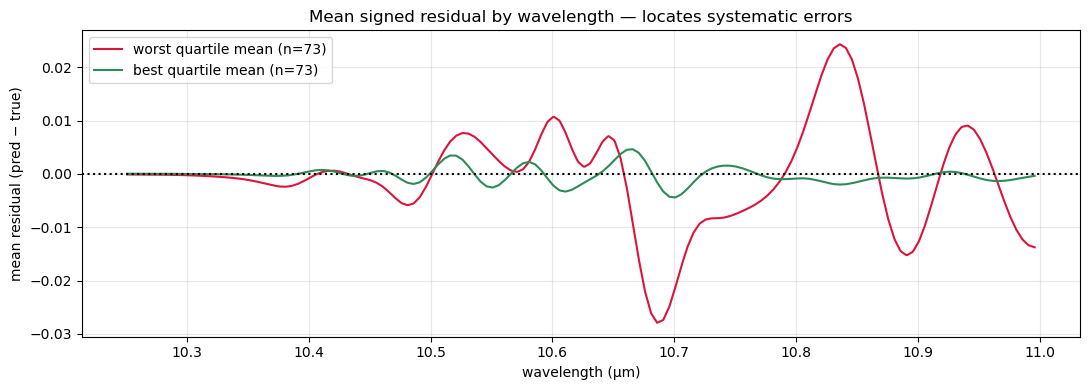

In [40]:
#### PER-PIXEL RESIDUAL HEATMAP ####
# Rows = test samples sorted by coeff_rmse (worst at top), cols = wavelength,
# color = pred - true reconstructed spectrum. Localizes the failure: if errors
# concentrate in a wavelength band, that band is systematically wrong.
resid_test = (pred_spec_t - true_spec_t).numpy()  # (N_test, n_wl)
order_desc = np.argsort(diag_test['coeff_rmse'].values)[::-1]
resid_sorted = resid_test[order_desc]
rmse_sorted  = diag_test['coeff_rmse'].values[order_desc]

vmax = np.abs(resid_sorted).max()
fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                         gridspec_kw={'width_ratios': [4, 1], 'wspace': 0.05})
ax_h, ax_r = axes
extent = [wl_plot.min(), wl_plot.max(), len(resid_sorted), 0]
im = ax_h.imshow(resid_sorted, aspect='auto', extent=extent,
                 cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
ax_h.set_xlabel('wavelength (Âµm)')
ax_h.set_ylabel('test sample (sorted: worst â†’ best)')
ax_h.set_title('Per-pixel residual  (pred âˆ’ true)')
fig.colorbar(im, ax=ax_h, label='residual')

ax_r.plot(rmse_sorted, np.arange(len(rmse_sorted)), color='k')
ax_r.fill_betweenx(np.arange(len(rmse_sorted)), 0, rmse_sorted, color='lightgrey')
ax_r.set_ylim(ax_h.get_ylim())
ax_r.set_xlabel('coeff_rmse')
ax_r.set_yticks([])
ax_r.set_title('per-sample RMSE')
ax_r.grid(alpha=0.3)

fig.suptitle('Localized failures across the test set', fontsize=13)
fig.tight_layout()
plt.show()

# Mean residual per pixel restricted to worst quartile vs best quartile
worst_mean_resid = resid_test[worst_mask].mean(axis=0)
best_mean_resid  = resid_test[best_mask].mean(axis=0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wl_plot, worst_mean_resid, color='crimson',
        label=f'worst quartile mean (n={worst_mask.sum()})')
ax.plot(wl_plot, best_mean_resid,  color='seagreen',
        label=f'best quartile mean (n={best_mask.sum()})')
ax.axhline(0, color='k', linestyle=':')
ax.set_xlabel('wavelength (Âµm)')
ax.set_ylabel('mean residual (pred âˆ’ true)')
ax.set_title('Mean signed residual by wavelength â€” locates systematic errors')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

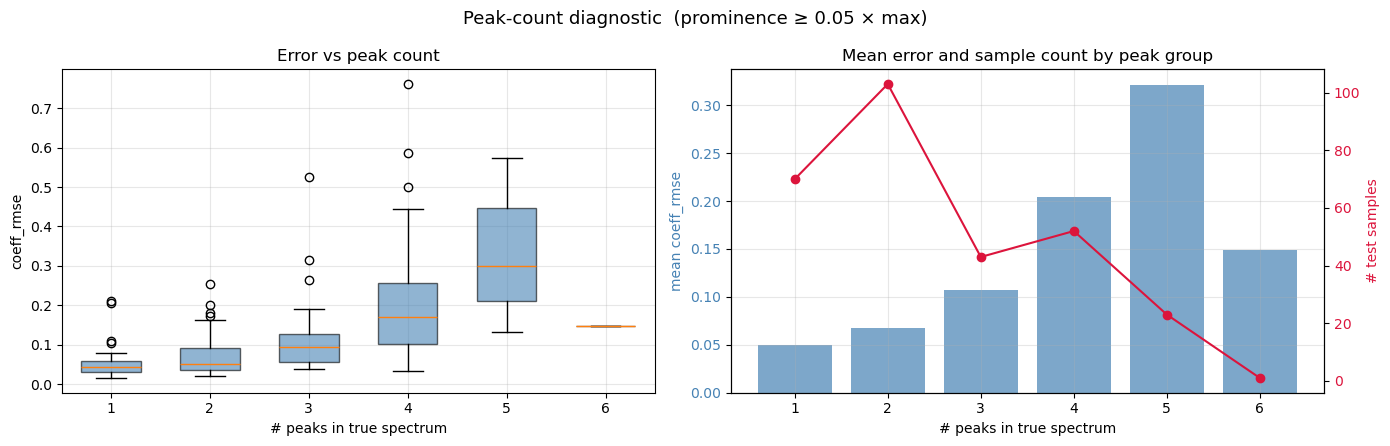


Spearman(n_peaks, coeff_rmse) = +0.677  (p=1.64e-40)
  1 peaks: mean coeff_rmse = 0.0497   (n=70)
  2 peaks: mean coeff_rmse = 0.0673   (n=103)
  3 peaks: mean coeff_rmse = 0.1076   (n=43)
  4 peaks: mean coeff_rmse = 0.2045   (n=52)
  5 peaks: mean coeff_rmse = 0.3213   (n=23)
  6 peaks: mean coeff_rmse = 0.1485   (n=1)


In [41]:
#### PEAK-COUNT DIAGNOSTIC ####
# Count peaks in the true spectrum per test sample and bin error by peak count.
# Tests the hypothesis that multi-peak shapes are the failure mode.
from scipy.signal import find_peaks

PROMINENCE = 0.05  # fraction of max
true_spec_np = true_spec_t.numpy()
peak_counts = np.array([
    len(find_peaks(s, prominence=PROMINENCE * s.max())[0])
    for s in true_spec_np
])

diag_test['n_peaks'] = peak_counts

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
unique_counts = np.sort(np.unique(peak_counts))

groups = [diag_test.loc[peak_counts == c, 'coeff_rmse'].values for c in unique_counts]
bp = axes[0].boxplot(groups, positions=unique_counts, widths=0.6,
                     patch_artist=True, showfliers=True)
for box in bp['boxes']:
    box.set_facecolor('steelblue'); box.set_alpha(0.6)
axes[0].set_xlabel('# peaks in true spectrum')
axes[0].set_ylabel('coeff_rmse')
axes[0].set_title('Error vs peak count')
axes[0].grid(alpha=0.3)

means = np.array([g.mean() if g.size else np.nan for g in groups])
counts_n = np.array([g.size for g in groups])
ax_b = axes[1]
ax_b.bar(unique_counts, means, color='steelblue', alpha=0.7, label='mean coeff_rmse')
ax_b.set_xlabel('# peaks in true spectrum')
ax_b.set_ylabel('mean coeff_rmse', color='steelblue')
ax_b.tick_params(axis='y', labelcolor='steelblue')
ax_b.grid(alpha=0.3)
ax_b2 = ax_b.twinx()
ax_b2.plot(unique_counts, counts_n, color='crimson', marker='o', label='# test samples')
ax_b2.set_ylabel('# test samples', color='crimson')
ax_b2.tick_params(axis='y', labelcolor='crimson')
ax_b.set_title('Mean error and sample count by peak group')

fig.suptitle(f'Peak-count diagnostic  (prominence â‰¥ {PROMINENCE} Ã— max)', fontsize=13)
fig.tight_layout()
plt.show()

sr_pk, sp_pk = spearmanr(peak_counts, diag_test['coeff_rmse'].values)
print(f"\nSpearman(n_peaks, coeff_rmse) = {sr_pk:+.3f}  (p={sp_pk:.2e})")
for c, m, n in zip(unique_counts, means, counts_n):
    print(f"  {c} peaks: mean coeff_rmse = {m:.4f}   (n={n})")

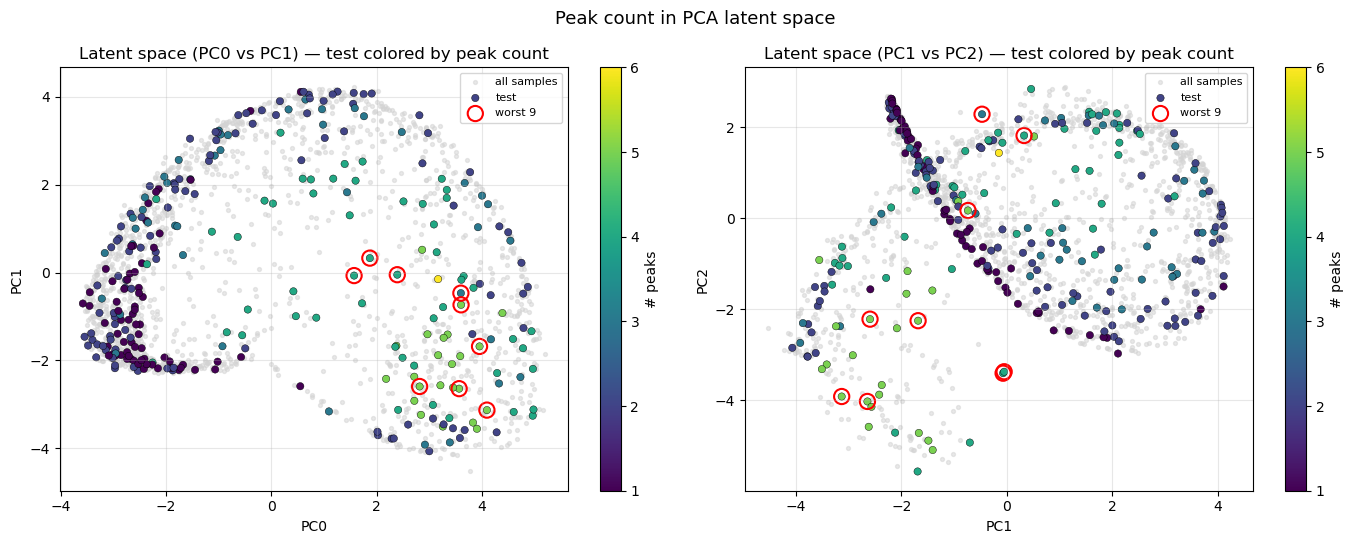

In [42]:
#### LATENT SPACE COLORED BY PEAK COUNT ####
# Re-run the latent-space scatter colored by n_peaks instead of error.
# Confirms (or refutes) that worst-N occupy the multi-peak region of latent space.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    ax.scatter(all_feat[:, i], all_feat[:, j], s=8, color='lightgrey',
               alpha=0.5, label='all samples')
    sc = ax.scatter(test_feat[:, i], test_feat[:, j],
                    c=peak_counts, cmap='viridis', s=28,
                    edgecolor='k', linewidth=0.3, label='test')
    ax.scatter(test_feat[worst_local, i], test_feat[worst_local, j],
               s=120, facecolors='none', edgecolor='red', linewidth=1.5,
               label=f'worst {N_WORST}')
    fig.colorbar(sc, ax=ax, label='# peaks')
    ax.set_xlabel(f'PC{i}')
    ax.set_ylabel(f'PC{j}')
    ax.set_title(f'Latent space (PC{i} vs PC{j}) â€” test colored by peak count')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')
fig.suptitle('Peak count in PCA latent space', fontsize=13)
fig.tight_layout()
plt.show()

Restricting to blw <= 2.7 (98 test samples).


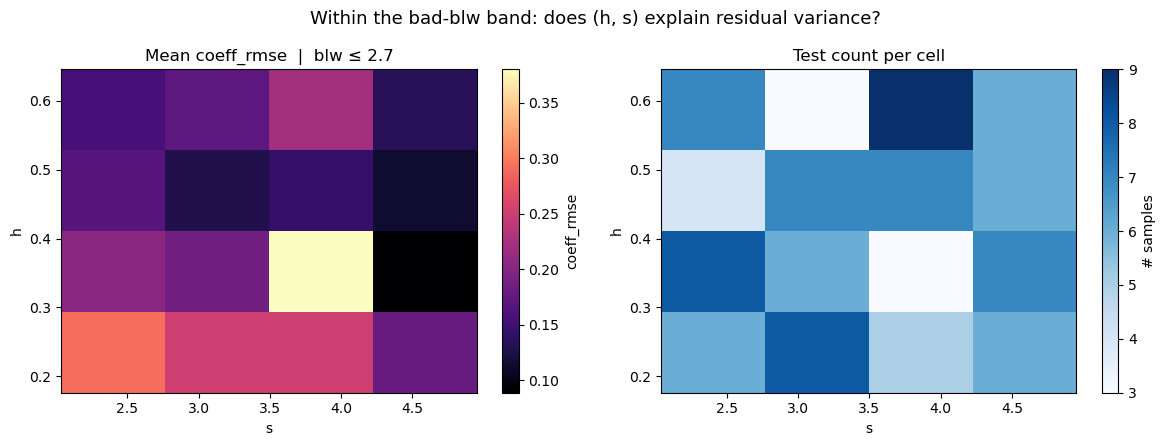

Within blw <= 2.7:  Spearman(h, rmse)=-0.179  Spearman(s, rmse)=-0.197


In [43]:
#### (h, s) HEATMAP RESTRICTED TO SMALL-BLW REGIME ####
# h and s have ~0 marginal correlation, but they may matter inside the bad
# (small blw) band. Restrict to the lower tertile of blw and show mean error
# over (h, s).
BLW_THRESH = np.quantile(diag_test['blw'].values, 1/3)
sub = diag_test[diag_test['blw'].values <= BLW_THRESH].copy()
geom_sub = geom_test[diag_test['blw'].values <= BLW_THRESH].copy()
print(f"Restricting to blw <= {BLW_THRESH:.3g} ({len(sub)} test samples).")

if len(sub) >= 10:
    n_b = 4
    h_edges = np.quantile(geom_sub['h'].values, np.linspace(0, 1, n_b + 1))
    s_edges = np.quantile(geom_sub['s'].values, np.linspace(0, 1, n_b + 1))
    h_edges[-1] += 1e-9; s_edges[-1] += 1e-9

    err_sum, _, _ = np.histogram2d(geom_sub['h'].values, geom_sub['s'].values,
                                   bins=[h_edges, s_edges],
                                   weights=sub['coeff_rmse'].values)
    cnt, _, _ = np.histogram2d(geom_sub['h'].values, geom_sub['s'].values,
                               bins=[h_edges, s_edges])
    mean_err_hs = np.where(cnt > 0, err_sum / np.maximum(cnt, 1), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    extent = [s_edges[0], s_edges[-1], h_edges[0], h_edges[-1]]
    im0 = axes[0].imshow(mean_err_hs, origin='lower', aspect='auto',
                         extent=extent, cmap='magma')
    axes[0].set_title(f'Mean coeff_rmse  |  blw â‰¤ {BLW_THRESH:.2g}')
    fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

    im1 = axes[1].imshow(cnt, origin='lower', aspect='auto',
                         extent=extent, cmap='Blues')
    axes[1].set_title('Test count per cell')
    fig.colorbar(im1, ax=axes[1], label='# samples')

    for ax in axes:
        ax.set_xlabel('s')
        ax.set_ylabel('h')
    fig.suptitle('Within the bad-blw band: does (h, s) explain residual variance?',
                 fontsize=13)
    fig.tight_layout()
    plt.show()

    sr_h, _ = spearmanr(geom_sub['h'].values, sub['coeff_rmse'].values)
    sr_s, _ = spearmanr(geom_sub['s'].values, sub['coeff_rmse'].values)
    print(f"Within blw <= {BLW_THRESH:.3g}:  Spearman(h, rmse)={sr_h:+.3f}  "
          f"Spearman(s, rmse)={sr_s:+.3f}")
else:
    print("Not enough samples in the small-blw band for a heatmap.")

Pearson(fold_std, coeff_rmse) = +0.770 (p=0.00e+00)
Spearman                       = +0.773 (p=2.95e-59)


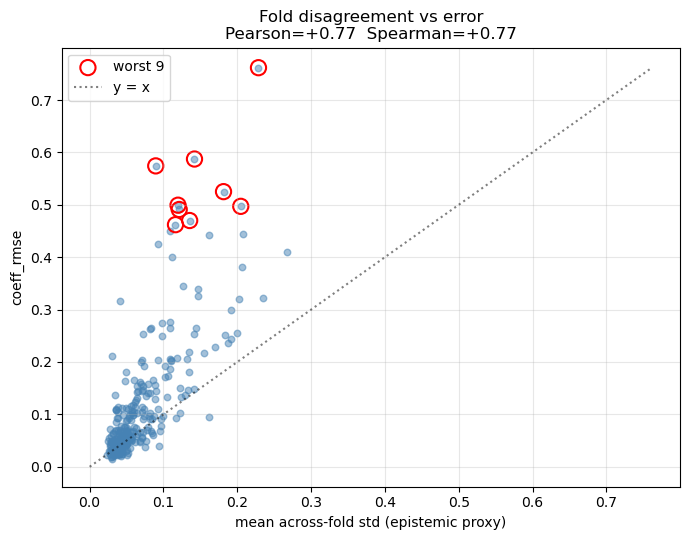

In [44]:
#### CV-FOLD DISAGREEMENT (EPISTEMIC PROXY) ####
# Std across the 4 fold-model coeff predictions per test sample. If samples the
# folds disagree on are also the ones with high error, disagreement is a free
# OOD / active-learning signal.
with torch.no_grad():
    fold_preds = torch.stack([m(geom_t)[0] for m in fold_models])  # (n_folds, N, K)
fold_std = fold_preds.std(dim=0).mean(dim=1).numpy()  # mean std across PCs per sample

pr_d, pp_d = pearsonr(fold_std, diag_test['coeff_rmse'].values)
sr_d, sp_d = spearmanr(fold_std, diag_test['coeff_rmse'].values)
print(f"Pearson(fold_std, coeff_rmse) = {pr_d:+.3f} (p={pp_d:.2e})")
print(f"Spearman                       = {sr_d:+.3f} (p={sp_d:.2e})")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(fold_std, diag_test['coeff_rmse'].values, alpha=0.5, s=22, color='steelblue')
ax.scatter(fold_std[worst_local], diag_test['coeff_rmse'].values[worst_local],
           s=120, facecolors='none', edgecolor='red', linewidth=1.5,
           label=f'worst {N_WORST}')
mx = max(fold_std.max(), diag_test['coeff_rmse'].max())
ax.plot([0, mx], [0, mx], color='k', linestyle=':', alpha=0.5, label='y = x')
ax.set_xlabel('mean across-fold std (epistemic proxy)')
ax.set_ylabel('coeff_rmse')
ax.set_title(f'Fold disagreement vs error\nPearson={pr_d:+.2f}  Spearman={sr_d:+.2f}')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

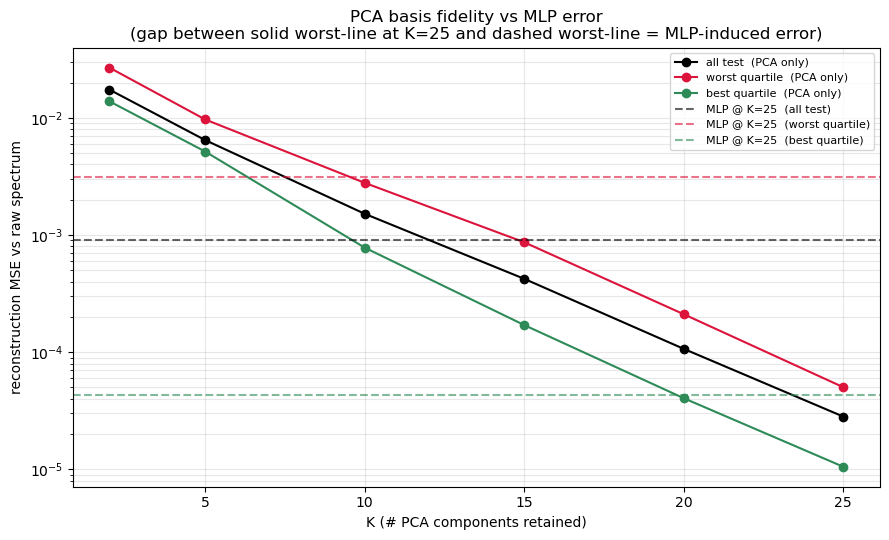


At K=25:
  PCA-only recon MSE  -- all: 0.00003   worst Q: 0.00005   best Q: 0.00001
  MLP recon MSE       -- all: 0.00091   worst Q: 0.00312   best Q: 0.00004
  MLP-induced share (worst Q): 98.4% of total error


In [45]:
#### K-SWEEP: WORST QUARTILE vs ALL  (PCA basis fidelity) ####
# Reconstruct each test spectrum from only the first K' coefficients of its
# TRUE PCA features (no MLP) and compare to the raw absorption. This isolates
# PCA-basis truncation error. If worst-quartile recon error >> all-test recon
# error, the basis itself fails on those geometries â†’ invest in a richer
# representation (more PCs, wavelets, MaxPeak features). If it's similar,
# the basis is fine and the MLP is the bottleneck â†’ invest in the predictor.
raw_test = _raw_abs[test_idx_arr]  # (N_test, n_wl)
K_max = feat_t.shape[1]
K_grid = sorted(set([k for k in [2, 5, 10, 15, 20, K_max] if k <= K_max]))

mse_all = []
mse_worst = []
mse_best = []
for K_try in K_grid:
    coeffs_trunc = feat_t.clone()
    coeffs_trunc[:, K_try:] = 0
    recon = data.reconstruct_spectrum(coeffs_trunc).numpy()  # (N_test, n_wl)
    sq = (recon - raw_test) ** 2
    mse_per_sample = sq.mean(axis=1)
    mse_all.append(mse_per_sample.mean())
    mse_worst.append(mse_per_sample[worst_mask].mean())
    mse_best.append(mse_per_sample[best_mask].mean())

# MLP-induced error at the trained K (current test recon error vs raw)
mlp_err_all   = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1).mean()
mlp_err_worst = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1)[worst_mask].mean()
mlp_err_best  = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1)[best_mask].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(K_grid, mse_all,   color='k',        marker='o', label='all test  (PCA only)')
ax.plot(K_grid, mse_worst, color='crimson',  marker='o', label='worst quartile  (PCA only)')
ax.plot(K_grid, mse_best,  color='seagreen', marker='o', label='best quartile  (PCA only)')
ax.axhline(mlp_err_all,   color='k',        linestyle='--', alpha=0.6, label='MLP @ K=25  (all test)')
ax.axhline(mlp_err_worst, color='crimson',  linestyle='--', alpha=0.6, label='MLP @ K=25  (worst quartile)')
ax.axhline(mlp_err_best,  color='seagreen', linestyle='--', alpha=0.6, label='MLP @ K=25  (best quartile)')
ax.set_yscale('log')
ax.set_xlabel('K (# PCA components retained)')
ax.set_ylabel('reconstruction MSE vs raw spectrum')
ax.set_title('PCA basis fidelity vs MLP error\n'
             '(gap between solid worst-line at K=25 and dashed worst-line = MLP-induced error)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8, loc='best')
fig.tight_layout()
plt.show()

print("\nAt K=25:")
print(f"  PCA-only recon MSE  -- all: {mse_all[-1]:.5f}   "
      f"worst Q: {mse_worst[-1]:.5f}   best Q: {mse_best[-1]:.5f}")
print(f"  MLP recon MSE       -- all: {mlp_err_all:.5f}   "
      f"worst Q: {mlp_err_worst:.5f}   best Q: {mlp_err_best:.5f}")
print(f"  MLP-induced share (worst Q): "
      f"{(mlp_err_worst - mse_worst[-1]) / max(mlp_err_worst, 1e-12) * 100:.1f}% of total error")

#### <span style="color:cyan">**Inverse Design - Lorentzian Target**</span>

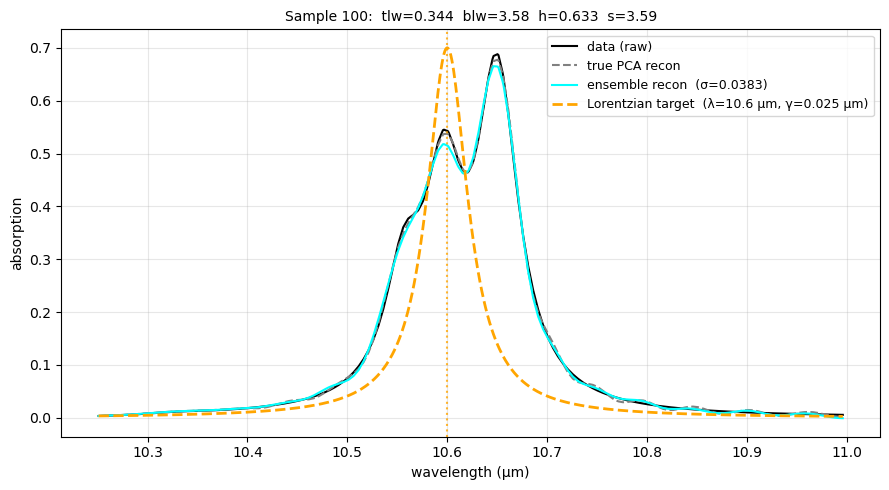

Predicted dominant peak: 10.5013 Âµm
Target peak:             10.6000 Âµm
Delta:                   98.7 nm
Ensemble uncertainty:    0.03829


In [49]:
#### LORENTZIAN TARGET ####

def make_lorentzian_target(wl: np.ndarray, lambda_target: float, gamma: float, A: float = 1.0) -> torch.Tensor:
    """Synthesize a Lorentzian absorption target on the given wavelength axis.
    lambda_target: peak center (Âµm), gamma: half-width at half-max (Âµm), A: peak amplitude.
    """
    wl_t = torch.tensor(wl, dtype=torch.float32)
    return A * 1.0 / (1.0 + ((wl_t - lambda_target) / gamma) ** 2)

#### CONFIG â€” edit these ####
SAMPLE_IDX    = 100    # dataset index to use as the reference reconstruction
LAMBDA_TARGET = 10.6   # desired peak center (Âµm), within domain (10.25â€“11.0)
GAMMA         = 0.025  # half-width at half-max (Âµm)
A_TARGET      = 0.7    # peak amplitude of the Lorentzian

#### BUILD TARGET CURVE ####
wl_np = np.asarray(data.wl)
target_t = make_lorentzian_target(wl_np, LAMBDA_TARGET, GAMMA, A_TARGET)

#### ENSEMBLE RECONSTRUCTION FOR SAMPLE_IDX ####
final_model_net.eval()
with torch.no_grad():
    geom_s    = data.geom[[SAMPLE_IDX]]                                          # (1, 4)
    pca_stack = torch.stack([m(geom_s)[0] for m in fold_models])                # (n_folds, 1, K)
    pk_stack  = torch.stack([m(geom_s)[1] for m in fold_models])                # (n_folds, 1, 3N)
    ens_pca   = pca_stack.mean(0)                                                # (1, K)
    ens_peaks = pk_stack.mean(0)                                                 # (1, 3N)
    ens_spec  = data.reconstruct_spectrum(ens_pca).squeeze().numpy()             # (L,)
    true_spec = data.reconstruct_spectrum(data.pca[[SAMPLE_IDX]]).squeeze().numpy()

    # Predicted peak lambda (highest-amplitude peak, rank 0) in Âµm
    peak_raw     = data.denormalize_amp(ens_peaks).view(data.n_peaks, 3)
    lambda_pred  = peak_raw[0, 0].item()
    # Ensemble uncertainty (std across folds, mean over PCs)
    ens_std      = pca_stack.std(0).mean().item()

raw_spec = _raw_abs[SAMPLE_IDX]

#### PLOT ####
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(wl_np, raw_spec,           color='k',         label='data (raw)')
ax.plot(wl_np, true_spec,          color='grey',       linestyle='--', label='true PCA recon')
ax.plot(wl_np, ens_spec,           color='cyan',       label=f'ensemble recon  (Ïƒ={ens_std:.4f})')
ax.plot(wl_np, target_t.numpy(),   color='orange',     linestyle='--', linewidth=2,
        label=f'Lorentzian target  (Î»={LAMBDA_TARGET} Âµm, Î³={GAMMA} Âµm)')
ax.axvline(LAMBDA_TARGET, color='orange', linestyle=':', alpha=0.8)

geom_row = pca_ft['geometry_table'].sort_index().iloc[SAMPLE_IDX]
geom_str = '  '.join(f'{c}={geom_row[c]:.3g}' for c in geom_row.index)
ax.set_title(f'Sample {SAMPLE_IDX}:  {geom_str}', fontsize=10)
ax.set_xlabel('wavelength (Âµm)')
ax.set_ylabel('absorption')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"Predicted dominant peak: {lambda_pred:.4f} Âµm")
print(f"Target peak:             {LAMBDA_TARGET:.4f} Âµm")
print(f"Delta:                   {abs(lambda_pred - LAMBDA_TARGET)*1e3:.1f} nm")
print(f"Ensemble uncertainty:    {ens_std:.5f}")